In [2]:
# Check which Python executable is being used
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Check if we're in the venv
if 'venv_py312' in sys.executable:
    print("✅ Using venv_py312 virtual environment")
else:
    print("❌ NOT using venv_py312 - using global Python installation")
    print(f"   Expected path should contain: venv_py312")
    print(f"   Actual path: {sys.executable}")

Python executable: c:\Users\Kaushik Maslekar\AppData\Local\Programs\Python\Python312\python.exe
Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
❌ NOT using venv_py312 - using global Python installation
   Expected path should contain: venv_py312
   Actual path: c:\Users\Kaushik Maslekar\AppData\Local\Programs\Python\Python312\python.exe


# Understanding RAG (Retrieval Augmented Generation) Implementation

RAG combines two main components:
1. **Retrieval**: Finding relevant information from a knowledge base
2. **Generation**: Using that information to generate accurate answers

## Phase 1: Setup and Data Preparation
- Loading and processing documents
- Converting text into chunks
- Creating embeddings for efficient searching
- Setting up the language model for generation

Let's go through each step in detail:

# Environment Setup
This section sets up all required dependencies and configurations for the Hugging Face environment.

In [2]:
# Install CUDA-enabled PyTorch
import sys
import subprocess

print("Installing PyTorch with CUDA 12.4 support...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", 
                    "torch", "--index-url", "https://download.pytorch.org/whl/cu124", "-q"])
print("PyTorch with CUDA support installed!")

# Install required packages
import subprocess

def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"{package} installed successfully!")

# Install essential packages
packages = [
    "huggingface_hub",
    "transformers",
    "accelerate",
    "bitsandbytes",
    "sentencepiece",
    "safetensors",
    "requests"
]

for package in packages:
    install_package(package)

print("All required packages installed successfully!")

Installing PyTorch with CUDA 12.4 support...
PyTorch with CUDA support installed!
All required packages installed successfully!


In [4]:

# Verify CUDA is available
import torch
print(f"\n✅ CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


✅ CUDA Available: False


In [ ]:
# Check CUDA availability and setup device settings
import torch
import transformers
import os

print("=" * 70)
print("GPU AVAILABILITY CHECK & CONFIGURATION")
print("=" * 70)

cuda_available = torch.cuda.is_available()
device = "cuda" if cuda_available else "cpu"

print("\n📊 System Information:")
print(f"  PyTorch Version: {torch.__version__}")
print(f"  Selected Device: {device.upper()}")

if cuda_available:
    # Check NVIDIA driver
    print("\n🔧 NVIDIA Driver Information:")
    os.system("nvidia-smi --query-gpu=name,driver_version,cuda_version --format=csv,noheader")

    gpu_count = torch.cuda.device_count()
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)

    print(f"\n✅ GPU IS AVAILABLE AND READY!")
    print(f"  Number of GPUs: {gpu_count}")
    print(f"  GPU Name: {gpu_name}")
    print(f"  GPU Memory: {gpu_memory:.2f} GB")
    if torch.version.cuda:
        print(f"  CUDA Version: {torch.version.cuda}")

    # Test GPU
    test_tensor = torch.randn(1000, 1000, device=device)
    allocated = torch.cuda.memory_allocated() / (1024**2)
    print(f"  Current GPU Memory Used: {allocated:.2f} MB")
    del test_tensor
    torch.cuda.empty_cache()

    # Set default device only when CUDA exists
    torch.set_default_device(device)
else:
    print("\n⚠️ CUDA is not available. Continuing on CPU.")
    print("   The notebook will still run, but embedding and generation will be slower.")

# Check BitsAndBytes
try:
    import bitsandbytes
    print(f"\n📦 Optional Libraries:")
    print(f"  BitsAndBytes: ✓ Available (for 4-bit/8-bit quantization)")
except ImportError:
    print(f"\n📦 Optional Libraries:")
    print(f"  BitsAndBytes: ✗ Not available")

print(f"\n✨ Environment Ready!")
print(f"  Device: {device.upper()}")
print(f"  PyTorch: {torch.__version__}")
print(f"  Transformers: {transformers.__version__}")
print("=" * 70 + "\n")


c:\Users\Kaushik Maslekar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU AVAILABILITY CHECK & CONFIGURATION

📊 System Information:
  PyTorch Version: 2.11.0+cu128

🔧 NVIDIA Driver Information:

✅ GPU IS AVAILABLE AND READY!
  Number of GPUs: 1
  GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
  GPU Memory: 4.00 GB
  CUDA Version: 12.8
  Current GPU Memory Used: 3.81 MB


W0417 13:16:30.432000 5588 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels



📦 Optional Libraries:
  BitsAndBytes: ✓ Available (for 4-bit/8-bit quantization)

✨ GPU Environment Ready!
  Device: CUDA
  PyTorch: 2.11.0+cu128
  Transformers: 4.57.6



In [3]:
# Install huggingface_hub if not already installed
try:
    import huggingface_hub
except ImportError:
    print("Installing huggingface_hub...")
    !pip install --quiet huggingface_hub

import os
import getpass
from huggingface_hub import login

# Prefer env vars over hardcoded tokens
hf_token = (
    os.getenv("HF_TOKEN")
    or os.getenv("HUGGINGFACEHUB_API_TOKEN")
    or os.getenv("HUGGINGFACE_HUB_TOKEN")
    or os.getenv("HUGGING_FACE_HUB_TOKEN")
)

if not hf_token:
    print("No Hugging Face token found in environment.")
    hf_token = getpass.getpass("Paste Hugging Face token (input hidden, press Enter to skip): ").strip()

if not hf_token:
    print("Skipped Hugging Face login. Set HF_TOKEN (or related env var) and rerun this cell.")
else:
    try:
        login(token=hf_token, add_to_git_credential=False)
        print("Successfully logged in to Hugging Face!")
    except Exception as e:
        print(f"Hugging Face login failed: {e}")
        print("Please verify your token and rerun this cell.")

No Hugging Face token found in environment.
Successfully logged in to Hugging Face!


In [4]:
# GPU Configuration - CUDA Required
import torch
import os

print("\n" + "=" * 70)
print("GPU CONFIGURATION (CUDA Required)")
print("=" * 70)

# Verify CUDA is available
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available! Please install Python 3.13 with PyTorch CUDA support.")

print("\n✅ CUDA Available - GPU Mode Enabled")
print(f"   Device: {torch.cuda.get_device_name(0)}")
print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# GPU Optimization Settings
print("\n🚀 Applying GPU Optimizations...")

# Enable cuDNN auto-tuner for best performance
torch.backends.cudnn.benchmark = True
print("  ✓ CuDNN auto-tuning enabled")

# Enable Flash Attention for faster computations
torch.backends.cuda.enable_flash_sdp(True)
print("  ✓ Flash Attention enabled (faster, lower memory)")

# Memory efficient mode
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
print("  ✓ CUDA memory optimization enabled")

# For RTX 3050 (4GB VRAM), use 90% of available memory
torch.cuda.set_per_process_memory_fraction(0.9)
print("  ✓ Memory fraction set to 90%")

# Clear GPU cache
torch.cuda.empty_cache()
print("  ✓ GPU cache cleared")

print("\n" + "=" * 70)
print("🎯 Ready for GPU acceleration! Starting embeddings on GPU...")
print("=" * 70)


GPU CONFIGURATION (CUDA Required)

✅ CUDA Available - GPU Mode Enabled
   Device: NVIDIA GeForce RTX 3050 Laptop GPU
   Memory: 4.0 GB

🚀 Applying GPU Optimizations...
  ✓ CuDNN auto-tuning enabled
  ✓ Flash Attention enabled (faster, lower memory)
  ✓ CUDA memory optimization enabled
  ✓ Memory fraction set to 90%
  ✓ GPU cache cleared

🎯 Ready for GPU acceleration! Starting embeddings on GPU...


## GPU Setup Status

### Current Status
- **GPU Detected**: ✅ NVIDIA RTX 3050 (4GB VRAM)
- **NVIDIA Drivers**: ✅ Installed (CUDA 13.1 capable)
- **PyTorch CUDA Support**: ❌ Not available for Python 3.14

### Issue
PyTorch 2.10.0 is compiled only for Python 3.13 and earlier. Python 3.14 requires newer PyTorch versions that aren't available yet on PyPI.

### Solutions

**Option 1: Use PyTorch CPU (Current)**
- Processing will use your CPU
- For embeddings with sentence-transformers, you can still use quantization
- Takes longer but produces same results

**Option 2: Downgrade Python (Recommended for GPU)**
```bash
# Install Python 3.13
python -m pip install --upgrade "python<3.14"
# Then reinstall PyTorch with CUDA support
```

**Option 3: Build PyTorch from source**
- Advanced option, requires CUDA toolkit and compiler
- See: https://github.com/pytorch/pytorch#from-source

In [5]:
# Notebook config: prompt for HF token and model selection (safer — no plaintext tokens saved)
# This cell will run interactively in the notebook. It sets the token only for the running kernel.
# Do NOT commit this notebook to version control if you enter a real token.
import os
import getpass

print("This cell will ask for your Hugging Face token (it will not be saved to disk).")
print("If you prefer to use an environment variable or the CLI, leave the token blank and press enter.")

try:
    token = getpass.getpass(prompt='Enter Hugging Face token (leave blank to skip): ')
except Exception:
    # In some notebook frontends getpass may not work; fall back to input with a warning
    print("Warning: secure prompt unavailable, using visible input.")
    token = input('Enter Hugging Face token (leave blank to skip): ')

if token:
    os.environ['HUGGINGFACE_HUB_TOKEN'] = token
    print('[CONFIG] Token set in-kernel for this session.')
else:
    print('[CONFIG] No token provided. Will use existing environment or anonymous access.')

# Prompt for model_id with a sensible default. Use an open model for quick testing if unsure.
def _input_with_default(prompt, default):
    resp = input(f"{prompt} [{default}]: ").strip()
    return resp if resp else default

default_model = 'google/gemma-2b-it'  # gated by default
chosen_model = _input_with_default('Model id to use (enter a model id or press enter for default)', default_model)

if chosen_model == default_model:
    print('\n[NOTICE] The default model is a gated model. Make sure you have accepted its terms on Hugging Face and that your token has access.')
    print('If you have not agreed to the model terms, consider using an open model like "sshleifer/tiny-gpt2" for testing.')

# Ask about quantization
use_q = _input_with_default('Use 4-bit quantization (y/N)', 'N')
use_quantization_config = use_q.lower().startswith('y')

# Publish into notebook globals so downstream cells can read them
globals()['model_id'] = chosen_model
globals()['use_quantization_config'] = use_quantization_config

print(f"\n[CONFIG] model_id={chosen_model}")
print(f"[CONFIG] use_quantization_config={use_quantization_config}")


This cell will ask for your Hugging Face token (it will not be saved to disk).
If you prefer to use an environment variable or the CLI, leave the token blank and press enter.
[CONFIG] Token set in-kernel for this session.

[NOTICE] The default model is a gated model. Make sure you have accepted its terms on Hugging Face and that your token has access.
If you have not agreed to the model terms, consider using an open model like "sshleifer/tiny-gpt2" for testing.

[CONFIG] model_id=google/gemma-2b-it
[CONFIG] use_quantization_config=False


# Hugging Face Authentication
First, we'll set up authentication with Hugging Face to access the models. You'll need to provide your Hugging Face token, which you can get from [your Hugging Face account settings](https://huggingface.co/settings/tokens).

In [6]:
# Install huggingface_hub if not already installed
try:
    import huggingface_hub
except ImportError:
    print("Installing huggingface_hub...")
    !pip install --quiet huggingface_hub

import os
import getpass
from huggingface_hub import login

# Prefer env vars over hardcoded tokens
hf_token = (
    os.getenv("HF_TOKEN")
    or os.getenv("HUGGINGFACEHUB_API_TOKEN")
    or os.getenv("HUGGINGFACE_HUB_TOKEN")
    or os.getenv("HUGGING_FACE_HUB_TOKEN")
    or globals().get("hf_token")
    or globals().get("token")
)

if not hf_token:
    print("No Hugging Face token found in environment.")
    hf_token = getpass.getpass("Paste Hugging Face token (input hidden, press Enter to skip): ").strip()

if not hf_token:
    print("Skipped Hugging Face login. Set HF_TOKEN (or related env var) and rerun this cell.")
else:
    try:
        login(token=hf_token, add_to_git_credential=False)
        print("Successfully logged in to Hugging Face!")
    except Exception as e:
        print(f"Hugging Face login failed: {e}")
        print("Please verify your token and rerun this cell.")

Successfully logged in to Hugging Face!


<a target="_blank" href="https://colab.research.google.com/github/mrdbourke/simple-local-rag/blob/main/00-simple-local-rag.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Create and run a local RAG pipeline from scratch

The goal of this notebook is to build a RAG (Retrieval Augmented Generation) pipeline from scratch and have it run on a local GPU.

Specifically, we'd like to be able to open a PDF file, ask questions (queries) of it and have them answered by a Large Language Model (LLM).

There are frameworks that replicate this kind of workflow, including [LlamaIndex](https://www.llamaindex.ai/) and [LangChain](https://www.langchain.com/), however, the goal of building from scratch is to be able to inspect and customize all the parts.

## What is RAG?

RAG stands for Retrieval Augmented Generation.

It was introduced in the paper [*Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*](https://arxiv.org/abs/2005.11401).

Each step can be roughly broken down to:

* **Retrieval** - Seeking relevant information from a source given a query. For example, getting relevant passages of Wikipedia text from a database given a question.
* **Augmented** - Using the relevant retrieved information to modify an input to a generative model (e.g. an LLM).
* **Generation** - Generating an output given an input. For example, in the case of an LLM, generating a passage of text given an input prompt.

## Why RAG?

The main goal of RAG is to improve the generation outptus of LLMs.

Two primary improvements can be seen as:
1. **Preventing hallucinations** - LLMs are incredible but they are prone to potential hallucination, as in, generating something that *looks* correct but isn't. RAG pipelines can help LLMs generate more factual outputs by providing them with factual (retrieved) inputs. And even if the generated answer from a RAG pipeline doesn't seem correct, because of retrieval, you also have access to the sources where it came from.
2. **Work with custom data** - Many base LLMs are trained with internet-scale text data. This means they have a great ability to model language, however, they often lack specific knowledge. RAG systems can provide LLMs with domain-specific data such as medical information or company documentation and thus customized their outputs to suit specific use cases.

The authors of the original RAG paper mentioned above outlined these two points in their discussion.

> This work offers several positive societal benefits over previous work: the fact that it is more
strongly grounded in real factual knowledge (in this case Wikipedia) makes it “hallucinate” less
with generations that are more factual, and offers more control and interpretability. RAG could be
employed in a wide variety of scenarios with direct benefit to society, for example by endowing it
with a medical index and asking it open-domain questions on that topic, or by helping people be more
effective at their jobs.

RAG can also be a much quicker solution to implement than fine-tuning an LLM on specific data. 



## What kind of problems can RAG be used for?

RAG can help anywhere there is a specific set of information that an LLM may not have in its training data (e.g. anything not publicly accessible on the internet).

For example you could use RAG for:
* **Customer support Q&A chat** - By treating your existing customer support documentation as a resource, when a customer asks a question, you could have a system retrieve relevant documentation snippets and then have an LLM craft those snippets into an answer. Think of this as a "chatbot for your documentation". Klarna, a large financial company, [uses a system like this](https://www.klarna.com/international/press/klarna-ai-assistant-handles-two-thirds-of-customer-service-chats-in-its-first-month/) to save $40M per year on customer support costs.
* **Email chain analysis** - Let's say you're an insurance company with long threads of emails between customers and insurance agents. Instead of searching through each individual email, you could retrieve relevant passages and have an LLM create strucutred outputs of insurance claims.
* **Company internal documentation chat** - If you've worked at a large company, you know how hard it can be to get an answer sometimes. Why not let a RAG system index your company information and have an LLM answer questions you may have? The benefit of RAG is that you will have references to resources to learn more if the LLM answer doesn't suffice.
* **Textbook Q&A** - Let's say you're studying for your exams and constantly flicking through a large textbook looking for answers to your quesitons. RAG can help provide answers as well as references to learn more.

All of these have the common theme of retrieving relevant resources and then presenting them in an understandable way using an LLM.

From this angle, you can consider an LLM a calculator for words.


## Why local?

Privacy, speed, cost.

Running locally means you use your own hardware.

From a privacy standpoint, this means you don't have send potentially sensitive data to an API.

From a speed standpoint, it means you won't necessarily have to wait for an API queue or downtime, if your hardware is running, the pipeline can run.

And from a cost standpoint, running on your own hardware often has a heavier starting cost but little to no costs after that.

Performance wise, LLM APIs may still perform better than an open-source model running locally on general tasks but there are more and more examples appearing of smaller, focused models outperforming larger models. 


## Key terms

| Term | Description |
| ----- | ----- | 
| **Token** | A sub-word piece of text. For example, "hello, world!" could be split into ["hello", ",", "world", "!"]. A token can be a whole word,<br> part of a word or group of punctuation characters. 1 token ~= 4 characters in English, 100 tokens ~= 75 words.<br> Text gets broken into tokens before being passed to an LLM. |
| **Embedding** | A learned numerical representation of a piece of data. For example, a sentence of text could be represented by a vector with<br> 768 values. Similar pieces of text (in meaning) will ideally have similar values. |
| **Embedding model** | A model designed to accept input data and output a numerical representation. For example, a text embedding model may take in 384 <br>tokens of text and turn it into a vector of size 768. An embedding model can and often is different to an LLM model. |
| **Similarity search/vector search** | Similarity search/vector search aims to find two vectors which are close together in high-demensional space. For example, <br>two pieces of similar text passed through an embedding model should have a high similarity score, whereas two pieces of text about<br> different topics will have a lower similarity score. Common similarity score measures are dot product and cosine similarity. |
| **Large Language Model (LLM)** | A model which has been trained to numerically represent the patterns in text. A generative LLM will continue a sequence when given a sequence. <br>For example, given a sequence of the text "hello, world!", a genertive LLM may produce "we're going to build a RAG pipeline today!".<br> This generation will be highly dependant on the training data and prompt. |
| **LLM context window** | The number of tokens a LLM can accept as input. For example, as of March 2024, GPT-4 has a default context window of 32k tokens<br> (about 96 pages of text) but can go up to 128k if needed. A recent open-source LLM from Google, Gemma (March 2024) has a context<br> window of 8,192 tokens (about 24 pages of text). A higher context window means an LLM can accept more relevant information<br> to assist with a query. For example, in a RAG pipeline, if a model has a larger context window, it can accept more reference items<br> from the retrieval system to aid with its generation. |
| **Prompt** | A common term for describing the input to a generative LLM. The idea of "[prompt engineering](https://en.wikipedia.org/wiki/Prompt_engineering)" is to structure a text-based<br> (or potentially image-based as well) input to a generative LLM in a specific way so that the generated output is ideal. This technique is<br> possible because of a LLMs capacity for in-context learning, as in, it is able to use its representation of language to breakdown <br>the prompt and recognize what a suitable output may be (note: the output of LLMs is probable, so terms like "may output" are used). | 




 ## What we're going to build

We're going to build RAG pipeline which enables us to chat with a PDF document, specifically an open-source [nutrition textbook](https://pressbooks.oer.hawaii.edu/humannutrition2/), ~1200 pages long.

You could call our project NutriChat!

We'll write the code to:
1. Open a PDF document (you could use almost any PDF here).
2. Format the text of the PDF textbook ready for an embedding model (this process is known as text splitting/chunking).
3. Embed all of the chunks of text in the textbook and turn them into numerical representation which we can store for later.
4. Build a retrieval system that uses vector search to find relevant chunks of text based on a query.
5. Create a prompt that incorporates the retrieved pieces of text.
6. Generate an answer to a query based on passages from the textbook.

The above steps can broken down into two major sections:
1. Document preprocessing/embedding creation (steps 1-3).
2. Search and answer (steps 4-6).

And that's the structure we'll follow.

It's similar to the workflow outlined on the NVIDIA blog which [details a local RAG pipeline](https://developer.nvidia.com/blog/rag-101-demystifying-retrieval-augmented-generation-pipelines/).

<img src="https://github.com/mrdbourke/simple-local-rag/blob/main/images/simple-local-rag-workflow-flowchart.png?raw=true" alt="flowchart of a local RAG workflow" />

## Requirements and setup

* Local NVIDIA GPU (I used a NVIDIA RTX 4090 on a Windows 11 machine) or Google Colab with access to a GPU.
* Environment setup (see [setup details on GitHub](https://github.com/mrdbourke/simple-local-rag/?tab=readme-ov-file#setup)).
* Data source (for example, a PDF). 
* Internet connection (to download the models, but once you have them, it'll run offline).

In [7]:
# Perform Google Colab installs (if running in Google Colab)
import os

if "COLAB_GPU" in os.environ:
    print("[INFO] Running in Google Colab, installing requirements.")
    !pip install -U torch # requires torch 2.1.1+ (for efficient sdpa implementation)
    !pip install PyMuPDF # for reading PDFs with Python
    !pip install tqdm # for progress bars
    !pip install sentence-transformers # for embedding models
    !pip install accelerate # for quantization model loading
    !pip install bitsandbytes # for quantizing models (less storage space)
    !pip install flash-attn --no-build-isolation # for faster attention mechanism = faster LLM inference

## 1. Document/Text Processing and Embedding Creation

Ingredients:
* PDF document of choice.
* Embedding model of choice.

Steps:
1. Import PDF document.
2. Process text for embedding (e.g. split into chunks of sentences).
3. Embed text chunks with embedding model.
4. Save embeddings to file for later use (embeddings will store on file for many years or until you lose your hard drive).

### Import PDF Document 

This will work with many other kinds of documents.

However, we'll start with PDF since many people have PDFs.

But just keep in mind, text files, email chains, support documentation, articles and more can also work.

We're going to work with the javabook.pdf document to build our knowledge base.

There are several libraries to open PDFs with Python but I found that [PyMuPDF](https://github.com/pymupdf/pymupdf) works quite well in many cases.

In [8]:
# Set PDF file path
import os
import requests

# Get PDF document
pdf_path = "Hands-On-LLM.pdf"

# Check if the file exists
if os.path.exists(pdf_path):
    print(f"File {pdf_path} exists and is ready to be processed.")
else:
    print(f"Error: {pdf_path} not found in the current directory")
    print(f"Current directory: {os.getcwd()}")
    print(f"Files in directory: {os.listdir('.')}")
    print("\nPlease ensure Hands-On-LLM.pdf is in the working directory.")

File Hands-On-LLM.pdf exists and is ready to be processed.


PDF acquired!

We can import the pages of our PDF to text by first defining the PDF path and then opening and reading it with PyMuPDF (`import fitz`).

We'll write a small helper function to preprocess the text as it gets read. Note that not all text will be read in the same so keep this in mind for when you prepare your text.

We'll save each page to a dictionary and then append that dictionary to a list for ease of use later.

In [9]:
# Fix PyMuPDF import issue (remove conflicting 'fitz' package, install pymupdf)
import sys
import subprocess

def _pip(args):
    subprocess.check_call([sys.executable, "-m", "pip", *args])

try:
    _pip(["uninstall", "-y", "fitz"])
except Exception:
    pass

_pip(["install", "-q", "pymupdf"])
print("PyMuPDF installed. You can now import fitz.")

PyMuPDF installed. You can now import fitz.


In [ ]:
# Requires !pip install PyMuPDF, see: https://github.com/pymupdf/pymupdf
import fitz # (pymupdf, found this is better than pypdf for our use case, note: licence is AGPL-3.0, keep that in mind if you want to use any code commercially)
from tqdm.auto import tqdm # for progress bars, requires !pip install tqdm 


def text_formatter(text: str) -> str:
    """Performs minor formatting on text."""
    cleaned_text = text.replace("\n", " ").strip() # note: this might be different for each doc (best to experiment)

    # Other potential text formatting functions can go here
    return cleaned_text


# Open PDF and get lines/pages
# Note: this only focuses on text, rather than images/figures etc
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text content page by page, and collects statistics.

    Parameters:
        pdf_path (str): The file path to the PDF document to be opened and read.

    Returns:
        list[dict]: A list of dictionaries, each containing the page number
        (adjusted), character count, word count, sentence count, token count, and the extracted text
        for each page.
    """
    doc = fitz.open(pdf_path)  # open a document
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # iterate the document pages
        # Use layout-aware extraction first, then fall back to blocks if the page looks empty.
        text = page.get_text("text", sort=True)
        if not text.strip():
            blocks = page.get_text("blocks")
            text = "\n".join(block[4] for block in blocks if len(block) > 4 and block[4].strip())

        text = text_formatter(text)
        pages_and_texts.append({"page_number": page_number,  # keep original page numbers
                                "page_char_count": len(text),
                                "page_word_count": len(text.split(" ")),
                                "page_sentence_count_raw": len(text.split(". ")),
                                "page_token_count": len(text) / 4,  # 1 token = ~4 chars, see: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
                                "text": text})
    return pages_and_texts


pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]


428it [00:00, 995.60it/s] 


[{'page_number': 0,
  'page_char_count': 110,
  'page_word_count': 20,
  'page_sentence_count_raw': 1,
  'page_token_count': 27.5,
  'text': 'Hands-On   Large Language  Models Language Understanding   and Generation Jay Alammar &   Maarten Grootendorst'},
 {'page_number': 1,
  'page_char_count': 2201,
  'page_word_count': 363,
  'page_sentence_count_raw': 10,
  'page_token_count': 550.25,
  'text': 'DATA “Jay and Maarten have  continued their tradition  of providing beautifully  illustrated and insightful  descriptions of complex  topics. Their book is  a valuable resource  for anyone looking to  understand the main  techniques behind how  large language models   are built.” —Andrew Ng founder of DeepLearning.AI “I can’t think of another book  that is more important to  read right now. On every  single page, I learned  something that is critical  to success in this era of  language models.” —Josh Starmer,  StatQuest Hands-On   Large Language Models linkedin.com/company/oreilly-media yo

Now let's get a random sample of the pages.

In [11]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 410,
  'page_char_count': 2148,
  'page_word_count': 332,
  'page_sentence_count_raw': 16,
  'page_token_count': 537.0,
  'text': '23 Jiwoo Hong, Noah Lee, and James Thorne, “ORPO: Monolithic preference optimization without reference model”. arXiv preprint arXiv:2403.07691 (2024).     low_cpu_mem_usage=True,     device_map="auto", ) sft_model = model.merge_and_unload() # Merge DPO LoRA and SFT model dpo_model = PeftModel.from_pretrained(     sft_model,     "TinyLlama-1.1B-dpo-qlora",     device_map="auto", ) dpo_model = dpo_model.merge_and_unload() This combination of SFT+DPO is a great way to first fine-tune your model to perform basic chatting and then align its answers with human preference. However, it does come at a cost since we need to perform two training loops and potentially tweak the parameters in two processes. Since the release of DPO, new methods of aligning preferences have been developed. Of note is Odds Ratio Preference Optimization (ORPO), a process t

### Get some stats on the text

Let's perform a rough exploratory data analysis (EDA) to get an idea of the size of the texts (e.g. character counts, word counts etc) we're working with.

The different sizes of texts will be a good indicator into how we should split our texts.

Many embedding models have limits on the size of texts they can ingest, for example, the [`sentence-transformers`](https://www.sbert.net/docs/pretrained_models.html) model [`all-mpnet-base-v2`](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) has an input size of 384 tokens.

This means that the model has been trained in ingest and turn into embeddings texts with 384 tokens (1 token ~= 4 characters ~= 0.75 words).

Texts over 384 tokens which are encoded by this model will be auotmatically reduced to 384 tokens in length, potentially losing some information.

We'll discuss this more in the embedding section.

For now, let's turn our list of dictionaries into a DataFrame and explore it.

In [12]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,0,110,20,1,27.50,Hands-On Large Language Models Language Und...
1,1,2201,363,10,550.25,DATA “Jay and Maarten have continued their tr...
2,2,1607,242,9,401.75,Praise for Hands-On Large Language Models This...
3,3,1835,277,15,458.75,This book is a must-read for anyone interested...
4,4,185,23,1,46.25,Jay Alammar and Maarten Grootendorst Hands-On ...


In [13]:
import pandas as pd
# Get stats
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,428.00,428.00,428.00,428.00,428.00
mean,213.50,1504.46,270.87,12.43,376.12
std,123.70,646.96,302.92,13.95,161.74
min,0.00,0.00,1.00,1.00,0.00
25%,106.75,1122.50,178.50,8.00,280.62
50%,213.50,1538.50,241.00,11.00,384.62
75%,320.25,1853.75,306.00,14.00,463.44
max,427.00,4455.00,3127.00,152.00,1113.75


Okay, looks like our average token count per page is 287.

For this particular use case, it means we could embed an average whole page with the `all-mpnet-base-v2` model (this model has an input capacity of 384).

### Further text processing (splitting pages into sentences)

The ideal way of processing text before embedding it is still an active area of research.

A simple method I've found helpful is to break the text into chunks of sentences.

As in, chunk a page of text into groups of 5, 7, 10 or more sentences (these values are not set in stone and can be explored).

But we want to follow the workflow of:

`Ingest text -> split it into groups/chunks -> embed the groups/chunks -> use the embeddings`

Some options for splitting text into sentences:

1. Split into sentences with simple rules (e.g. split on ". " with `text = text.split(". ")`, like we did above).
2. Split into sentences with a natural language processing (NLP) library such as [spaCy](https://spacy.io/) or [nltk](https://www.nltk.org/).

Why split into sentences?

* Easier to handle than larger pages of text (especially if pages are densely filled with text).
* Can get specific and find out which group of sentences were used to help within a RAG pipeline.

> **Resource:** See [spaCy install instructions](https://spacy.io/usage). 

Let's use spaCy to break our text into sentences since it's likely a bit more robust than just using `text.split(". ")`. 

In [15]:
# Use a simple regular-expression sentence splitter to avoid extra NLP dependencies
import re

def sentence_tokenizer(text):
    """Simple sentence tokenizer that splits on sentence endings."""
    # Split on sentence boundaries (period, exclamation, question mark followed by space)
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

# Test the sentence tokenizer
test_text = "This is a sentence. This is another sentence."
sents = sentence_tokenizer(test_text)
assert len(sents) == 2, f"Expected 2 sentences, got {len(sents)}"
print(f"Sentence tokenizer works! Found {len(sents)} sentences in test text.")
sents

Sentence tokenizer works! Found 2 sentences in test text.


['This is a sentence.', 'This is another sentence.']

We don't necessarily need to use spaCy, however, it's an open-source library designed to do NLP tasks like this at scale.

So let's run our small sentencizing pipeline on our pages of text.

In [16]:
for item in tqdm(pages_and_texts):
    item["sentences"] = sentence_tokenizer(item["text"])
    
    # Count the sentences
    item["page_sentence_count_nltk"] = len(item["sentences"])

100%|██████████| 428/428 [00:00<00:00, 32926.07it/s]


In [17]:
# Inspect an example
import random
random.sample(pages_and_texts, k=1)

[{'page_number': 347,
  'page_char_count': 1943,
  'page_word_count': 267,
  'page_sentence_count_raw': 9,
  'page_token_count': 485.75,
  'text': '1 Jacob Devlin et al. “BERT: Pre-training of deep bidirectional transformers for language understanding.” arXiv preprint arXiv:1810.04805 (2018). The first step in our classification task is to select the underlying model we want to use. We use "bert-base-cased", which was pretrained on the English Wikipedia as well as a large dataset consisting of unpublished books.1 We define the number of labels that we want to predict beforehand. This is necessary to create the feedforward neural network that is applied on top of our pretrained model: from transformers import AutoTokenizer, AutoModelForSequenceClassification # Load model and tokenizer model_id = "bert-base-cased" model = AutoModelForSequenceClassification.from_pretrained(     model_id, num_labels=2 ) tokenizer = AutoTokenizer.from_pretrained(model_id) Next, we will tokenize our data: fr

Wonderful!

Now let's turn out list of dictionaries into a DataFrame and get some stats.

In [18]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_nltk
count,428.00,428.00,428.00,428.00,428.00,428.00
mean,213.50,1504.46,270.87,12.43,376.12,12.85
std,123.70,646.96,302.92,13.95,161.74,14.11
min,0.00,0.00,1.00,1.00,0.00,0.00
25%,106.75,1122.50,178.50,8.00,280.62,8.00
50%,213.50,1538.50,241.00,11.00,384.62,11.00
75%,320.25,1853.75,306.00,14.00,463.44,15.00
max,427.00,4455.00,3127.00,152.00,1113.75,153.00


For our set of text, it looks like our raw sentence count (e.g. splitting on `". "`) is quite close to what spaCy came up with.

Now we've got our text split into sentences, how about we gorup those sentences?

### Chunking our sentences together

Let's take a step to break down our list of sentences/text into smaller chunks.

As you might've guessed, this process is referred to as **chunking**.

Why do we do this?

1. Easier to manage similar sized chunks of text.
2. Don't overload the embedding models capacity for tokens (e.g. if an embedding model has a capacity of 384 tokens, there could be information loss if you try to embed a sequence of 400+ tokens).
3. Our LLM context window (the amount of tokens an LLM can take in) may be limited and requires compute power so we want to make sure we're using it as well as possible.

Something to note is that there are many different ways emerging for creating chunks of information/text.

For now, we're going to keep it simple and break our pages of sentences into groups of 10 (this number is arbitrary and can be changed, I just picked it because it seemed to line up well with our embedding model capacity of 384).

On average each of our pages has 10 sentences.

And an average total of 287 tokens per page.

So our groups of 10 sentences will also be ~287 tokens long.

This gives us plenty of room for the text to embedded by our `all-mpnet-base-v2` model (it has a capacity of 384 tokens).

To split our groups of sentences into chunks of 10 or less, let's create a function which accepts a list as input and recursively breaks into down into sublists of a specified size.

In [19]:
# Define split size to turn groups of sentences into chunks
num_sentence_chunk_size = 10 

# Create a function that recursively splits a list into desired sizes
def split_list(input_list: list, 
               slice_size: int) -> list[list[str]]:
    """
    Splits the input_list into sublists of size slice_size (or as close as possible).

    For example, a list of 17 sentences would be split into two lists of [[10], [7]]
    """
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Loop through pages and texts and split sentences into chunks
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

100%|██████████| 428/428 [00:00<00:00, 428031.02it/s]


In [20]:
# Sample an example from the group (note: many samples have only 1 chunk as they have <=10 sentences total)
random.sample(pages_and_texts, k=1)

[{'page_number': 17,
  'page_char_count': 1660,
  'page_word_count': 248,
  'page_sentence_count_raw': 17,
  'page_token_count': 415.0,
  'text': 'This element signifies a tip or suggestion. This element signifies a general note. Using Code Examples Supplemental material (code examples, exercises, etc.) is available for download at https://github.com/HandsOnLLM/Hands-On-Large-Language-Models. If you have a technical question or a problem using the code examples, please send email to support@oreilly.com. This book is here to help you get your job done. In general, if example code is offered with this book, you may use it in your programs and documentation. You do not need to contact us for permission unless you’re reproducing a significant portion of the code. For example, writing a program that uses several chunks of code from this book does not require permission. Selling or distributing examples from O’Reilly books does require permission. Answering a question by citing this book and

In [21]:
# Create a DataFrame to get stats
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_nltk,num_chunks
count,428.00,428.00,428.00,428.00,428.00,428.00,428.00
mean,213.50,1504.46,270.87,12.43,376.12,12.85,1.76
std,123.70,646.96,302.92,13.95,161.74,14.11,1.44
min,0.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,106.75,1122.50,178.50,8.00,280.62,8.00,1.00
50%,213.50,1538.50,241.00,11.00,384.62,11.00,2.00
75%,320.25,1853.75,306.00,14.00,463.44,15.00,2.00
max,427.00,4455.00,3127.00,152.00,1113.75,153.00,16.00


Note how the average number of chunks is around 1.5, this is expected since many of our pages only contain an average of 10 sentences.

### Splitting each chunk into its own item

We'd like to embed each chunk of sentences into its own numerical representation.

So to keep things clean, let's create a new list of dictionaries each containing a single chunk of sentences with relative information such as page number as well statistics about each chunk.

In [22]:
import re

# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]
        
        # Join the sentences together into a paragraph-like structure, aka a chunk (so they are a single string)
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk) # ".A" -> ". A" for any full-stop/capital letter combo 
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Get stats about the chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters
        
        pages_and_chunks.append(chunk_dict)

# How many chunks do we have?
len(pages_and_chunks)

100%|██████████| 428/428 [00:00<00:00, 32927.28it/s]


754

In [23]:
# View a random sample
random.sample(pages_and_chunks, k=1)

[{'page_number': 278,
  'sentence_chunk': '2 Nelson F. Liu, Tianyi Zhang, and Percy Liang.“Evaluating verifiability in generative search engines.” arXiv preprint arXiv:2304.09848 (2023). RAG Evaluation There are still ongoing developments in how to evaluate RAG models. A good paper to read on this topic is “Evaluating verifiability in generative search engines” (2023), which runs human evaluations on different generative search systems.2 It evaluates results along four axes: Fluency Whether the generated text is fluent and cohesive. Perceived utility Whether the generated answer is helpful and informative. Citation recall The proportion of generated statements about the external world that are fully supported by their citations. Citation precision The proportion of generated citations that support their associated statements. While human evaluation is always preferred, there are approaches that attempt to automate these evaluations by having a capable LLM act as a judge (called LLM-as-

Excellent!

Now we've broken our whole textbook into chunks of 10 sentences or less as well as the page number they came from.

This means we could reference a chunk of text and know its source.

Let's get some stats about our chunks.

In [24]:
# Get stats about our chunks
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,754.00,754.00,754.00,754.00
mean,193.99,837.46,137.66,209.37
std,130.19,562.44,106.20,140.61
min,0.00,10.00,1.00,2.50
25%,71.25,340.00,53.00,85.00
50%,195.50,879.00,141.00,219.75
75%,307.75,1215.75,194.00,303.94
max,427.00,2559.00,976.00,639.75


Hmm looks like some of our chunks have quite a low token count.

How about we check for samples with less than 30 tokens (about the length of a sentence) and see if they are worth keeping?

In [25]:
# Show random chunks with under 30 tokens in length
min_token_length = 30
filtered_df = df[df["chunk_token_count"] <= min_token_length]
num_samples = min(5, len(filtered_df))  # Sample up to 5, or less if not enough
for row in filtered_df.sample(min(num_samples, len(filtered_df))).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 2.5 | Text: ..........
Chunk token count: 2.5 | Text: ..........
Chunk token count: 2.5 | Text: ..........
Chunk token count: 2.5 | Text: ..........
Chunk token count: 2.5 | Text: ..........


Looks like many of these are headers and footers of different pages.

They don't seem to offer too much information.

Let's filter our DataFrame/list of dictionaries to only include chunks with over 30 tokens in length.

In [26]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': 1,
  'sentence_chunk': 'DATA “Jay and Maarten have continued their tradition of providing beautifully illustrated and insightful descriptions of complex topics. Their book is a valuable resource for anyone looking to understand the main techniques behind how large language models  are built.” —Andrew Ng founder of DeepLearning. AI “I can’t think of another book that is more important to read right now. On every single page, I learned something that is critical to success in this era of language models.” —Josh Starmer, StatQuest Hands-On  Large Language Models linkedin.com/company/oreilly-media youtube.com/oreillymedia AI has acquired startling new language capabilities in just  the past few years. Driven by rapid advances in deep learning, language AI systems are able to write and understand text better than ever before. This trend is enabling new features, products, and entire industries. Through this book’s visually educational nature, readers will learn practical to

Smaller chunks filtered!

Time to embed our chunks of text!

### Embedding our text chunks

While humans understand text, machines understand numbers best.

An [embedding](https://vickiboykis.com/what_are_embeddings/index.html) is a broad concept.

But one of my favourite and simple definitions is "a useful numerical representation".

The most powerful thing about modern embeddings is that they are *learned* representations.

Meaning rather than directly mapping words/tokens/characters to numbers directly (e.g. `{"a": 0, "b": 1, "c": 3...}`), the numerical representation of tokens is learned by going through large corpuses of text and figuring out how different tokens relate to each other.

Ideally, embeddings of text will mean that similar meaning texts have similar numerical representation.

> **Note:** Most modern NLP models deal with "tokens" which can be considered as multiple different sizes and combinations of words and characters rather than always whole words or single characters. For example, the string `"hello world!"` gets mapped to the token values `{15339: b'hello', 1917: b' world', 0: b'!'}` using [Byte pair encoding](https://en.wikipedia.org/wiki/Byte_pair_encoding) (or BPE via OpenAI's [`tiktoken`](https://github.com/openai/tiktoken) library). Google has a tokenization library called [SentencePiece](https://github.com/google/sentencepiece).

Our goal is to turn each of our chunks into a numerical representation (an embedding vector, where a vector is a sequence of numbers arranged in order).

Once our text samples are in embedding vectors, us humans will no longer be able to understand them.

However, we don't need to.

The embedding vectors are for our computers to understand.

We'll use our computers to find patterns in the embeddings and then we can use their text mappings to further our understanding.

Enough talking, how about we import a text embedding model and see what an embedding looks like.

To do so, we'll use the [`sentence-transformers`](https://www.sbert.net/docs/installation.html) library which contains many pre-trained embedding models.

Specifically, we'll get the `all-mpnet-base-v2` model (you can see the model's intended use on the [Hugging Face model card](https://huggingface.co/sentence-transformers/all-mpnet-base-v2#intended-uses)).

In [27]:
# Ensure required dependencies are available and version-compatible
import sys
import subprocess
import torch

def _pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

def _pip_uninstall(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", pkg])

# Pin to a known-compatible stack for sentence-transformers
_pip_install(
    "sentence-transformers==2.7.0",
    "transformers==4.41.2",
    "huggingface-hub==0.23.5",
    "tokenizers==0.19.1"
)

# Clean up a broken torchvision install (common source of import crashes in this env)
try:
    import torchvision  # noqa: F401
except Exception:
    try:
        _pip_uninstall("torchvision")
    except Exception:
        pass

# Drop partially imported modules from this kernel session before importing again
for mod in list(sys.modules):
    if mod.startswith("torchvision") or mod.startswith("transformers") or mod.startswith("sentence_transformers") or mod.startswith("huggingface_hub"):
        sys.modules.pop(mod, None)

from sentence_transformers import SentenceTransformer

# Use GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

embedding_model = SentenceTransformer(
    model_name_or_path="all-mpnet-base-v2",
    device=device
)  # GPU will be much faster than CPU

# Create a list of sentences to turn into numbers
sentences = [
    "The Sentences Transformers library provides an easy and open-source way to create embeddings.",
    "Sentences can be embedded one by one or as a list of strings.",
    "Embeddings are one of the most powerful concepts in machine learning!",
    "Learn to use embeddings well and you'll be well on your way to being an AI engineer."
]

# Sentences are encoded/embedded by calling model.encode()
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# See the embeddings
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Embedding:", embedding)
    print("")

Using device: cuda


c:\Users\Kaushik Maslekar\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Sentence: The Sentences Transformers library provides an easy and open-source way to create embeddings.
Embedding: [-2.07981374e-02  3.03164218e-02 -2.01218128e-02  6.86483532e-02
 -2.55255643e-02 -8.47689621e-03 -2.07111196e-04 -6.32377416e-02
  2.81606149e-02 -3.33353467e-02  3.02634798e-02  5.30721173e-02
 -5.03526777e-02  2.62287464e-02  3.33313905e-02 -4.51578945e-02
  3.63044366e-02 -1.37112767e-03 -1.20171290e-02  1.14946542e-02
  5.04510924e-02  4.70857136e-02  2.11913381e-02  5.14607430e-02
 -2.03746390e-02 -3.58889140e-02 -6.67873712e-04 -2.94393301e-02
  4.95858900e-02 -1.05639435e-02 -1.52013786e-02 -1.31752936e-03
  4.48196791e-02  1.56022888e-02  8.60379657e-07 -1.21391716e-03
 -2.37978864e-02 -9.09424969e-04  7.34484987e-03 -2.53933878e-03
  5.23369685e-02 -4.68043461e-02  1.66214611e-02  4.71579283e-02
 -4.15599123e-02  9.01962689e-04  3.60279009e-02  3.42214443e-02
  9.68227684e-02  5.94828688e-02 -1.64984874e-02 -3.51249352e-02
  5.92517806e-03 -7.07964529e-04 -2.4103

Woah! That's a lot of numbers.

How about we do just once sentence?

In [72]:
single_sentence = "Yo! whassup?"
single_embedding = embedding_model.encode(single_sentence)
print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")

Sentence: Yo! whassup?
Embedding:
[ 3.68286557e-02  4.79659392e-03  2.23764144e-02 -2.44581439e-02
  2.96422234e-03  8.32100678e-03 -3.53665315e-02 -2.59763654e-03
  5.42108854e-03 -2.96586473e-02  7.02853920e-03 -1.28487423e-02
  2.45810561e-02  4.09333967e-02  4.78798561e-02 -4.07448336e-02
  3.40906791e-02 -6.73905686e-02 -7.36353770e-02 -2.62316391e-02
  1.31256005e-03  2.85040941e-02 -4.50537987e-02  7.15060085e-02
 -2.50537097e-02 -1.35456193e-02 -4.14202921e-02 -1.76377911e-02
  1.70189925e-02  3.07655670e-02  5.18323444e-02  9.24416166e-03
 -1.35389091e-02  6.32966682e-03  2.05952256e-06  7.87415821e-03
 -6.13767188e-03  1.94318481e-02 -2.36096662e-02  1.12892203e-02
 -3.01857218e-02 -1.72707438e-02 -6.90514967e-02  2.75667235e-02
 -3.13208476e-02  5.85952774e-03  2.50700023e-02 -2.98240185e-02
 -6.75911270e-03 -1.85519941e-02 -1.26428287e-02 -5.25805093e-02
 -2.44511832e-02 -2.66011746e-04  6.85242862e-02 -5.37174530e-02
  3.40635814e-02 -4.65658028e-03  4.41778339e-02 -5.4980

Nice! We've now got a way to numerically represent each of our chunks.

Our embedding has a shape of `(768,)` meaning it's a vector of 768 numbers which represent our text in high-dimensional space, too many for a human to comprehend but machines love high-dimensional space.

> **Note:** No matter the size of the text input to our `all-mpnet-base-v2` model, it will be turned into an embedding size of `(768,)`. This value is fixed. So whether a sentence is 1 token long or 1000 tokens long, it will be truncated/padded with zeros to size 384 and then turned into an embedding vector of size `(768,)`. Of course, other embedding models may have different input/output shapes.

How about we add an embedding field to each of our chunk items?

Let's start by trying to create embeddings on the CPU, we'll time it with the `%%time` magic to see how long it takes.

In [ ]:
# Token-aware chunking with a small sentence overlap.
# This keeps chunks closer to the embedding model's real token budget than a fixed sentence count.
from copy import deepcopy

max_tokens_per_chunk = 300
chunk_overlap_sentences = 1
min_token_length = 30

if not pages_and_texts or "sentences" not in pages_and_texts[0]:
    raise RuntimeError("Sentence lists are missing. Run the sentence tokenization cells before chunking.")

# Use the SentenceTransformer tokenizer so the chunk size reflects the embedding model's tokenization.
def count_model_tokens(text: str) -> int:
    return len(embedding_model.tokenizer(text, add_special_tokens=True, truncation=False)["input_ids"])


def build_token_aware_chunks(sentences: list[str], max_tokens: int, overlap_sentences: int = 1) -> list[str]:
    chunks = []
    current_sentences = []
    current_tokens = 0

    for sentence in sentences:
        cleaned_sentence = sentence.strip()
        if not cleaned_sentence:
            continue

        sentence_tokens = count_model_tokens(cleaned_sentence)
        if current_sentences and current_tokens + sentence_tokens > max_tokens:
            chunks.append(" ".join(current_sentences).strip())
            current_sentences = current_sentences[-overlap_sentences:] if overlap_sentences else []
            current_tokens = sum(count_model_tokens(item) for item in current_sentences)

        current_sentences.append(cleaned_sentence)
        current_tokens += sentence_tokens

    if current_sentences:
        chunks.append(" ".join(current_sentences).strip())

    return chunks


pages_and_chunks = []
for item in pages_and_texts:
    token_aware_sentence_chunks = build_token_aware_chunks(
        sentences=item["sentences"],
        max_tokens=max_tokens_per_chunk,
        overlap_sentences=chunk_overlap_sentences,
    )

    for sentence_chunk in token_aware_sentence_chunks:
        chunk_dict = {
            "page_number": item["page_number"],
            "sentence_chunk": sentence_chunk,
            "chunk_char_count": len(sentence_chunk),
            "chunk_word_count": len(sentence_chunk.split()),
            "chunk_token_count": count_model_tokens(sentence_chunk),
        }
        pages_and_chunks.append(chunk_dict)

# Keep only the chunks that are large enough to be useful.
df = pd.DataFrame(pages_and_chunks)
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] >= min_token_length].to_dict(orient="records")

print(f"Built {len(pages_and_chunks)} token-aware chunks; {len(pages_and_chunks_over_min_token_len)} remain after filtering.")
print(df[["chunk_token_count", "page_number"]].describe().round(2))


In [ ]:
%%time
# Reuse the token-aware chunks created above and embed them on GPU if available.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {device}")
embedding_model.to(device)

if "pages_and_chunks_over_min_token_len" not in globals():
    raise RuntimeError("Token-aware chunks were not prepared. Run the chunking cell first.")

# Create embeddings one by one on GPU
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])


🚀 Using device: cuda


100%|██████████| 647/647 [00:19<00:00, 33.18it/s]

CPU times: total: 17.7 s
Wall time: 19.5 s


Ok not too bad... but this would take a *really* long time if we had a larger dataset.

Now let's see how long it takes to create the embeddings with a GPU.

In [74]:
%%time

# Use GPU (CUDA) for ultra-fast embedding generation
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device for batch processing: {device}")
embedding_model.to(device)

# Create embeddings in batch mode on GPU
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

🚀 Using device for batch processing: cuda


100%|██████████| 647/647 [00:19<00:00, 32.81it/s]

CPU times: total: 18.1 s
Wall time: 19.7 s


Woah! Looks like the embeddings get created much faster (~10x faster on my machine) on the GPU!

You'll likely notice this trend with many of your deep learning workflows. If you have access to a GPU, especially a NVIDIA GPU, you should use one if you can.

But what if I told you we could go faster again?

You see many modern models can handle batched predictions.

This means computing on multiple samples at once.

Those are the types of operations where a GPU flourishes!

We can perform batched operations by turning our target text samples into a single list and then passing that list to our embedding model.

In [28]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

In [29]:
%%time

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(text_chunks,
                                               batch_size=32, # you can use different batch sizes here for speed/performance, I found 32 works well for this use case
                                               convert_to_tensor=True) # optional to return embeddings as tensor instead of array

text_chunk_embeddings

CPU times: total: 13.3 s
Wall time: 12.8 s


tensor([[ 0.0384,  0.0219, -0.0086,  ..., -0.0053, -0.0842, -0.0264],
        [ 0.0418,  0.0406, -0.0131,  ..., -0.0308, -0.0977, -0.0223],
        [ 0.0229,  0.0636, -0.0504,  ...,  0.0251, -0.0528, -0.0559],
        ...,
        [ 0.0031, -0.0301, -0.0097,  ...,  0.0429,  0.0212,  0.0212],
        [ 0.0202,  0.0324, -0.0560,  ...,  0.0646,  0.0066, -0.0119],
        [ 0.0404,  0.0993,  0.0209,  ..., -0.0020,  0.0771, -0.0156]],
       device='cuda:0')

That's what I'm talking about!

A ~4x improvement (on my GPU) in speed thanks to batched operations.

So the tip here is to use a GPU when you can and use batched operations if you can too.

Now let's save our chunks and their embeddings so we could import them later if we wanted.

### Save embeddings to file

Since creating embeddings can be a timely process (not so much for our case but it can be for more larger datasets), let's turn our `pages_and_chunks_over_min_token_len` list of dictionaries into a DataFrame and save it.

In [80]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

And we can make sure it imports nicely by loading it.

In [31]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count
0,1,DATA “Jay and Maarten have continued their tra...,2160,322,540.00
1,2,Praise for Hands-On Large Language Models This...,1486,219,371.50
2,3,This book is a must-read for anyone interested...,1252,187,313.00
3,3,"By the final chapters, you will be fine-tuning...",577,85,144.25
4,4,Jay Alammar and Maarten Grootendorst Hands-On ...,185,23,46.25


### Chunking and embedding questions

> **Which embedding model should I use?**

This depends on many factors. My best advice is to experiment, experiment, experiment! 

If you want the model to run locally, you'll have to make sure it's feasible to run on your own hardware. 

A good place to see how different models perform on a wide range of embedding tasks is the [Hugging Face Massive Text Embedding Benchmark (MTEB) Leaderboard](https://huggingface.co/spaces/mteb/leaderboard).

> **What other forms of text chunking/splitting are there?**

There are a fair few options here too. We've kept it simple with groups of sentences.

For more, [Pinecone has a great guide on different kinds of chunking](https://www.pinecone.io/learn/chunking-strategies/) including for different kinds of data such as markdown and LaTeX.

Libraries such as [LangChain also have a good amount of in-built text splitting options](https://python.langchain.com/docs/modules/data_connection/document_transformers/).

> **What should I think about when creating my embeddings?**

Our model turns text inputs up to 384 tokens long in embedding vectors of size 768.

Generally, the larger the vector size, the more information that gets encoded into the embedding (however, this is not always the case, as smaller, better models can outperform larger ones).

Though with larger vector sizes comes larger storage and compute requirements.

Our model is also relatively small (420MB) in size compared to larger models that are available.

Larger models may result in better performance but will also require more compute.

So some things to think about:
* Size of input - If you need to embed longer sequences, choose a model with a larger input capacity.
* Size of embedding vector - Larger is generally a better representation but requires more compute/storage.
* Size of model - Larger models generally result in better embeddings but require more compute power/time to run.
* Open or closed - Open models allow you to run them on your own hardware whereas closed models can be easier to setup but require an API call to get embeddings.

> **Where should I store my embeddings?**

If you've got a relatively small dataset, for example, under 100,000 examples (this number is rough and only based on first hand experience), `np.array` or `torch.tensor` can work just fine as your dataset.

But if you've got a production system and want to work with 100,000+ embeddings, you may want to look into a [vector database]( https://en.wikipedia.org/wiki/Vector_database) (these have become very popular lately and there are many offerings).

### Document Ingestion and Embedding Creation Extensions

One major extension to the workflow above would to functionize it.

Or turn it into a script.

As in, take all the functionality we've created and package it into a single process (e.g. go from document -> embeddings file).

So you could input a document on one end and have embeddings come out the other end. The hardest part of this is knowing what kind of preprocessing your text may need before it's turned into embeddings. Cleaner text generally means better results.



## 2. RAG - Search and Answer

We discussed RAG briefly in the beginning but let's quickly recap.

RAG stands for Retrieval Augmented Generation.

Which is another way of saying "given a query, search for relevant resources and answer based on those resources".

Let's breakdown each step:
* **Retrieval** - Get relevant resources given a query. For example, if the query is "what are the macronutrients?" the ideal results will contain information about protein, carbohydrates and fats (and possibly alcohol) rather than information about which tractors are the best for farming (though that is also cool information).
* **Augmentation** - LLMs are capable of generating text given a prompt. However, this generated text is designed to *look* right. And it often has some correct information, however, they are prone to hallucination (generating a result that *looks* like legit text but is factually wrong). In augmentation, we pass relevant information into the prompt and get an LLM to use that relevant information as the basis of its generation.
* **Generation** - This is where the LLM will generate a response that has been flavoured/augmented with the retrieved resources. In turn, this not only gives us a potentially more correct answer, it also gives us resources to investigate more (since we know which resources went into the prompt).

The whole idea of RAG is to get an LLM to be more factually correct based on your own input as well as have a reference to where the generated output may have come from.

This is an incredibly helpful tool.

Let's say you had 1000s of customer support documents.

You could use RAG to generate direct answers to questions with links to relevant documentation.

Or you were an insurance company with large chains of claims emails.

You could use RAG to answer questions about the emails with sources.

One helpful analogy is to think of LLMs as calculators for words.

With good inputs, the LLM can sort them into helpful outputs.

How? 

It starts with better search.

### Similarity search

Similarity search or semantic search or vector search is the idea of searching on *vibe*.

If this sounds like woo, woo. It's not.

Perhaps searching via *meaning* is a better analogy.

With keyword search, you are trying to match the string "apple" with the string "apple".

Whereas with similarity/semantic search, you may want to search "macronutrients functions".

And get back results that don't necessarily contain the words "macronutrients functions" but get back pieces of text that match that meaning.

> **Example:** Using similarity search on our textbook data with the query "macronutrients function" returns a paragraph that starts with: 
>
>*There are three classes of macronutrients: carbohydrates, lipids, and proteins. These can be metabolically processed into cellular energy. The energy from macronutrients comes from their chemical bonds. This chemical energy is converted into cellular energy that is then utilized to perform work, allowing our bodies to conduct their basic functions.*
> 
> as the first result. How cool!

If you've ever used Google, you know this kind of workflow.

But now we'd like to perform that across our own data.

Let's import our embeddings we created earlier (tk -link to embedding file) and prepare them for use by turning them into a tensor.

In [76]:
import random

import torch
import numpy as np 
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

# Import texts and embedding df
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

if "embedding" in text_chunks_and_embedding_df.columns:
    # Convert embedding column back to np.array (it got converted to string when it got saved to CSV)
    text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

    # Convert texts and embedding df to list of dicts
    pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

    # Convert embeddings to torch tensor and send to device (note: NumPy arrays are float64, torch tensors are float32 by default)
    embeddings = torch.tensor(np.array(text_chunks_and_embedding_df["embedding"].tolist()), dtype=torch.float32).to(device)
else:
    print("[INFO] CSV does not contain an embedding column; reusing the embeddings already created in memory.")
    pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")
    embeddings = torch.as_tensor(embeddings, dtype=torch.float32).to(device)

embeddings.shape

[INFO] CSV does not contain an embedding column; reusing the embeddings already created in memory.


torch.Size([4, 768])

In [77]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count
0,1,DATA “Jay and Maarten have continued their tra...,2160,322,540.00
1,2,Praise for Hands-On Large Language Models This...,1486,219,371.50
2,3,This book is a must-read for anyone interested...,1252,187,313.00
3,3,"By the final chapters, you will be fine-tuning...",577,85,144.25
4,4,Jay Alammar and Maarten Grootendorst Hands-On ...,185,23,46.25


In [78]:
embeddings[0]

tensor([-2.0798e-02,  3.0316e-02, -2.0122e-02,  6.8648e-02, -2.5526e-02,
        -8.4769e-03, -2.0711e-04, -6.3238e-02,  2.8161e-02, -3.3335e-02,
         3.0263e-02,  5.3072e-02, -5.0353e-02,  2.6229e-02,  3.3331e-02,
        -4.5158e-02,  3.6304e-02, -1.3711e-03, -1.2017e-02,  1.1495e-02,
         5.0451e-02,  4.7086e-02,  2.1191e-02,  5.1461e-02, -2.0375e-02,
        -3.5889e-02, -6.6787e-04, -2.9439e-02,  4.9586e-02, -1.0564e-02,
        -1.5201e-02, -1.3175e-03,  4.4820e-02,  1.5602e-02,  8.6038e-07,
        -1.2139e-03, -2.3798e-02, -9.0942e-04,  7.3448e-03, -2.5393e-03,
         5.2337e-02, -4.6804e-02,  1.6621e-02,  4.7158e-02, -4.1560e-02,
         9.0196e-04,  3.6028e-02,  3.4221e-02,  9.6823e-02,  5.9483e-02,
        -1.6498e-02, -3.5125e-02,  5.9252e-03, -7.0796e-04, -2.4103e-02,
         3.4974e-02, -2.9475e-02,  6.0427e-03, -9.8065e-03,  2.8322e-02,
        -1.8538e-02,  3.6321e-02,  1.3029e-02, -3.7123e-02,  5.2726e-02,
        -1.1971e-02, -7.1808e-02,  1.2443e-02, -6.7

Nice!

Now let's prepare another instance of our embedding model. Not because we have to but because we'd like to make it so you can start the notebook from the cell above. 

In [79]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", 
                                      device=device) # choose the device to load the model to

c:\Users\Kaushik Maslekar\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [151]:
from sentence_transformers import util
import torch


def retrieve_relevant_resources(query, embeddings, k=3):
    """Return the top-k similarity scores and indices for a query."""
    query_embedding = embedding_model.encode(query, convert_to_tensor=True)
    query_embedding = torch.as_tensor(query_embedding, dtype=torch.float32).cpu()
    embeddings_for_search = torch.as_tensor(embeddings, dtype=torch.float32).cpu()

    if query_embedding.ndim == 1:
        query_embedding = query_embedding.unsqueeze(0)

    scores = util.dot_score(query_embedding, embeddings_for_search)[0]
    top_k = min(k, scores.shape[0])
    top_scores, top_indices = torch.topk(scores, k=top_k)
    return top_scores.tolist(), top_indices.tolist()

Embedding model ready!

Time to perform a semantic search.

Let's say you were studying the macronutrients.

And wanted to search your textbook for "macronutrients functions".

Well, we can do so with the following steps:
1. Define a query string (e.g. `"macronutrients functions"`) - note: this could be anything, specific or not.
2. Turn the query string in an embedding with same model we used to embed our text chunks.
3. Perform a [dot product](https://pytorch.org/docs/stable/generated/torch.dot.html) or [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) function between the text embeddings and the query embedding (we'll get to what these are shortly) to get similarity scores.
4. Sort the results from step 3 in descending order (a higher score means more similarity in the eyes of the model) and use these values to inspect the texts. 

Easy!


In [153]:
# 1. Define the query
query = "LLM?"
print(f"Query: {query}")

# 2. Embed the query to the same numerical space as the text examples
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. Get similarity scores with the dot product
from time import perf_counter as timer
start_time = timer()
dot_scores = util.dot_score(query_embedding, embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# 4. Get the top-k results, but never ask for more items than exist
k = min(5, dot_scores.shape[0])
top_results_dot_product = torch.topk(dot_scores, k=k)
top_results_dot_product

Query: LLM?
Time take to get scores on 4 embeddings: 0.00025 seconds.


torch.return_types.topk(
values=tensor([ 0.0804,  0.0546,  0.0239, -0.0077], device='cuda:0'),
indices=tensor([1, 3, 2, 0], device='cuda:0'))

Woah!! Now that was fast!

~0.00008 seconds to perform a dot product comparison across 1680 embeddings on my machine (NVIDIA RTX 4090 GPU).

GPUs are optimized for these kinds of operations.

So even if you we're to increase our embeddings by 100x (1680 -> 168,000), an exhaustive dot product operation would happen in ~0.008 seconds (assuming linear scaling).

Heck, let's try it.

In [150]:
larger_embeddings = torch.randn(100*embeddings.shape[0], 768).to(device)
print(f"Embeddings shape: {larger_embeddings.shape}")

# Perform dot product across 168,000 embeddings
start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=larger_embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(larger_embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

Embeddings shape: torch.Size([400, 768])
Time take to get scores on 400 embeddings: 0.00196 seconds.


Wow. That's quick!

That means we can get pretty far by just storing our embeddings in `torch.tensor` for now.

However, for *much* larger datasets, we'd likely look at a dedicated vector database/indexing libraries such as [Faiss](https://github.com/facebookresearch/faiss).

Let's check the results of our original similarity search.

[`torch.topk`](https://pytorch.org/docs/stable/generated/torch.topk.html) returns a tuple of values (scores) and indicies for those scores.

The indicies relate to which indicies in the `embeddings` tensor have what scores in relation to the query embedding (higher is better).

We can use those indicies to map back to our text chunks.

First, we'll define a small helper function to print out wrapped text (so it doesn't print a whole text chunk as a single line).

In [42]:
# Define helper function to print wrapped text 
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

Now we can loop through the `top_results_dot_product` tuple and match up the scores and indicies and then use those indicies to index on our `pages_and_chunks` variable to get the relevant text chunk.

Sounds like a lot but we can do it!

In [154]:
print(f"Query: '{query}'\n")
print("Results:")
# Loop through zipped together scores and indicies from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    # Print the page number too so we can reference the textbook further (and check the results)
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'LLM?'

Results:
Score: 0.0804
Text:
Praise for Hands-On Large Language Models This is an exceptional guide to the
world of language models and their practical applications in industry. Its
highly-visual coverage of generative, representational, and retrieval
applications of language models empowers readers to quickly understand, use, and
refine LLMs. Highly recommended!—Nils Reimers, Director of Machine Learning at
Cohere | creator of sentence-transformers Jay and Maarten have continued their
tradition of providing beautifully illustrated and insightful descriptions of
complex topics in their new book. Bolstered with working code, timelines, and
references to key papers, their book is a valuable resource for anyone looking
to understand the main techniques behind how Large Language Models are
built.—Andrew Ng, founder of DeepLearning. AI I can’t think of another book that
is more important to read right now. On every single page, I learned something
that is critical to success 

The first result looks to have nailed it!

We get a very relevant answer to our query `"macronutrients functions"` even though its quite vague.

That's the power of semantic search!

And even better, if we wanted to inspect the result further, we get the page number where the text appears.

How about we check the page to verify?

We can do so by loading the page number containing the highest result (page 5 but really page 5 + 41 since our PDF page numbers start on page 41).

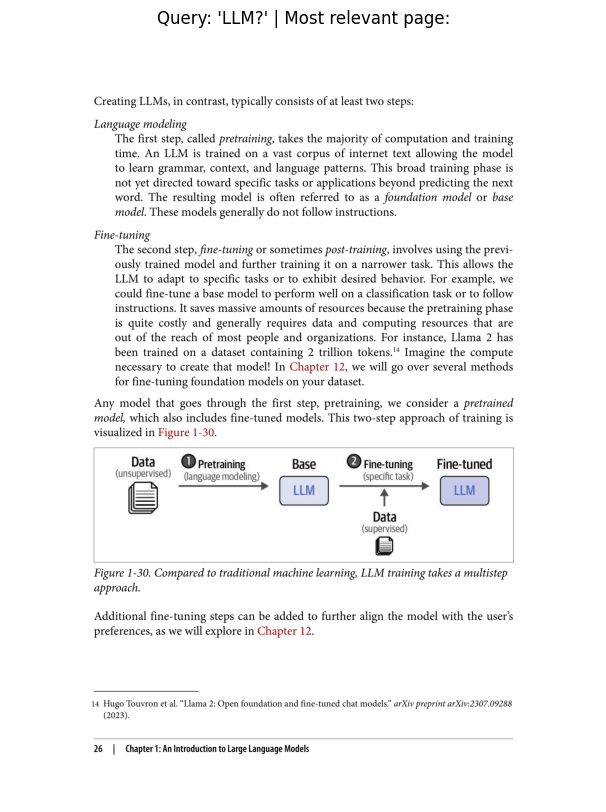

In [152]:
from pathlib import Path
import fitz

# Open PDF and load target page
pdf_path = "Hands-On-LLM.pdf"  # requires PDF to be downloaded
pdf_file = Path(pdf_path)

if not pdf_file.exists():
    print(f"Skipping page preview: {pdf_path} is not present in the workspace.")
else:
    doc = fitz.open(pdf_path)
    page = doc.load_page(5 + 42)  # number of page (our doc starts page numbers on page 41)

    # Get the image of the page
    img = page.get_pixmap(dpi=300)

    # Optional: save the image
    # img.save("output_filename.png")
    doc.close()

    # Convert the Pixmap to a numpy array
    img_array = np.frombuffer(img.samples_mv, dtype=np.uint8).reshape((img.h, img.w, img.n))

    # Display the image using Matplotlib
    import matplotlib.pyplot as plt
    plt.figure(figsize=(13, 10))
    plt.imshow(img_array)
    plt.title(f"Query: '{query}' | Most relevant page:")
    plt.axis('off')  # Turn off axis
    plt.show()

Nice!

Now we can do extra research if we'd like.

We could repeat this workflow for any kind of query we'd like on our textbook.

And it would also work for other datatypes too.

We could use semantic search on customer support documents.

Or email threads.

Or company plans.

Or our old journal entries.

Almost anything!

The workflow is the same:

`ingest documents -> split into chunks -> embed chunks -> make a query -> embed the query -> compare query embedding to chunk embeddings`

And we get relevant resources *along with* the source they came from!

That's the **retrieval** part of Retrieval Augmented Generation (RAG).

Before we get to the next two steps, let's take a small aside and discuss similarity measures.

### Similarity measures: dot product and cosine similarity 

Let's talk similarity measures between vectors.

Specifically, embedding vectors which are representations of data with magnitude and direction in high dimensional space (our embedding vectors have 768 dimensions).

Two of the most common you'll across are the dot product and cosine similarity.

They are quite similar.

The main difference is that cosine similarity has a normalization step.

| Similarity measure | Description | Code |
| ----- | ----- | ----- |
| [Dot Product](https://en.wikipedia.org/wiki/Dot_product) | - Measure of magnitude and direction between two vectors<br>- Vectors that are aligned in direction and magnitude have a higher positive value<br>- Vectors that are opposite in direction and magnitude have a higher negative value | [`torch.dot`](https://pytorch.org/docs/stable/generated/torch.dot.html), [`np.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html), [`sentence_transformers.util.dot_score`](https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.dot_score) | 
| [Cosine Similarity](https://en.wikipedia.org/wiki/Cosine_similarity) | - Vectors get normalized by magnitude/[Euclidean norm](https://en.wikipedia.org/wiki/Norm_(mathematics))/L2 norm so they have unit length and are compared more so on direction<br>- Vectors that are aligned in direction have a value close to 1<br>- Vectors that are opposite in direction have a value close to -1 | [`torch.nn.functional.cosine_similarity`](https://pytorch.org/docs/stable/generated/torch.nn.functional.cosine_similarity.html), [`1 - scipy.spatial.distance.cosine`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html) (subtract the distance from 1 for similarity measure), [`sentence_transformers.util.cos_sim`](https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.cos_sim) |

For text similarity, you generally want to use cosine similarity as you are after the semantic measurements (direction) rather than magnitude. 

In our case, our embedding model `all-mpnet-base-v2` outputs normalized outputs (see the [Hugging Face model card](https://huggingface.co/sentence-transformers/all-mpnet-base-v2#usage-huggingface-transformers) for more on this) so dot product and cosine similarity return the same results. However, dot product is faster due to not need to perform a normalize step.

To make things bit more concrete, let's make simple dot product and cosine similarity functions and view their results on different vectors.

> **Note:** Similarity measures between vectors and embeddings can be used on any kind of embeddings, not just text embeddings. For example, you could measure image embedding similarity or audio embedding similarity. Or with text and image models like [CLIP](https://github.com/mlfoundations/open_clip), you can measure the similarity between text and image embeddings.

In [84]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # Get Euclidean/L2 norm of each vector (removes the magnitude, keeps direction)
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_vector1 * norm_vector2)

# Example tensors
vector1 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector2 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector3 = torch.tensor([4, 5, 6], dtype=torch.float32)
vector4 = torch.tensor([-1, -2, -3], dtype=torch.float32)

# Calculate dot product
print("Dot product between vector1 and vector2:", dot_product(vector1, vector2))
print("Dot product between vector1 and vector3:", dot_product(vector1, vector3))
print("Dot product between vector1 and vector4:", dot_product(vector1, vector4))

# Calculate cosine similarity
print("Cosine similarity between vector1 and vector2:", cosine_similarity(vector1, vector2))
print("Cosine similarity between vector1 and vector3:", cosine_similarity(vector1, vector3))
print("Cosine similarity between vector1 and vector4:", cosine_similarity(vector1, vector4))

Dot product between vector1 and vector2: tensor(14., device='cuda:0')
Dot product between vector1 and vector3: tensor(32., device='cuda:0')
Dot product between vector1 and vector4: tensor(-14., device='cuda:0')
Cosine similarity between vector1 and vector2: tensor(1.0000, device='cuda:0')
Cosine similarity between vector1 and vector3: tensor(0.9746, device='cuda:0')
Cosine similarity between vector1 and vector4: tensor(-1.0000, device='cuda:0')


Notice for both dot product and cosine similarity the comparisons of `vector1` and `vector2` are the opposite of `vector1` and `vector4`.

Comparing `vector1` and `vector2` both equations return positive values (14 for dot product and 1.0 for cosine similarity). 

But comparing `vector1` and `vector4` the result is in the negative direction.

This makes sense because `vector4` is the negative version of `vector1`.

Whereas comparing `vector1` and `vector3` shows a different outcome.

For the dot product, the value is positive and larger then the comparison of two exactly the same vectors (32 vs 14).

However, for the cosine similarity, thanks to the normalization step, comparing `vector1` and `vector3` results in a postive value close to 1 but not exactly 1.

It is because of this that when comparing text embeddings, cosine similarity is generally favoured as it measures the difference in direction of a pair of vectors rather than difference in magnitude.

And it is this difference in direction that is more generally considered to capture the semantic meaning/vibe of the text.

The good news is that as mentioned before, the outputs of our embedding model `all-mpnet-base-v2` are already normalized.

So we can continue using the dot product (cosine similarity is dot product + normalization).

With similarity measures explained, let's functionize our semantic search steps from above so we can repeat them. 

### Functionizing our semantic search pipeline

Let's put all of the steps from above for semantic search into a function or two so we can repeat the workflow.

In [85]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query, convert_to_tensor=True)
    query_embedding = torch.as_tensor(query_embedding, dtype=torch.float32).cpu()
    embeddings_for_search = torch.as_tensor(embeddings, dtype=torch.float32).cpu()

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings_for_search)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings_for_search)} embeddings: {end_time-start_time:.5f} seconds.")

    top_k = min(n_resources_to_return, dot_scores.shape[0])
    scores, indices = torch.topk(input=dot_scores,
                                 k=top_k)

    return scores, indices


def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.

    Note: Requires pages_and_chunks to be formatted in a specific way (see above for reference).
    """
    
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)
    
    print(f"Query: {query}\n")
    print("Results:")
    # Loop through zipped together scores and indicies
    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        # Print the page number too so we can reference the textbook further and check the results
        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

Excellent! Now let's test our functions out.

In [50]:
query = "symptoms of pellagra"

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Time taken to get scores on 4 embeddings: 0.00008 seconds.


(tensor([-0.0229, -0.0450, -0.0983, -0.1060]), tensor([1, 0, 2, 3]))

In [51]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on 4 embeddings: 0.00009 seconds.
Query: symptoms of pellagra

Results:
Score: -0.0229
DATA “Jay and Maarten have continued their tradition of providing beautifully
illustrated and insightful descriptions of complex topics. Their book is a
valuable resource for anyone looking to understand the main techniques behind
how large language models  are built.” —Andrew Ng founder of DeepLearning. AI “I
can’t think of another book that is more important to read right now. On every
single page, I learned something that is critical to success in this era of
language models.” —Josh Starmer, StatQuest Hands-On  Large Language Models
linkedin.com/company/oreilly-media youtube.com/oreillymedia AI has acquired
startling new language capabilities in just  the past few years. Driven by rapid
advances in deep learning, language AI systems are able to write and understand
text better than ever before. This trend is enabling new features, products, and
entire industries. Th

### Semantic search/vector search extensions 

We've covered an exmaple of using embedding vector search to find relevant results based on a query.

However, you could also add to this pipeline with traditional keyword search.

Many modern search systems use keyword and vector search in tandem.

Our dataset is small and allows for an exhaustive search (comparing the query to *every* possible result) but if you start to work with large scale datasets with hundred of thousands, millions or even billions of vectors, you'll want to implement an index.

You can think of an index as sorting your embeddings before you search through them.

So it narrows down the search space.

For example, it would be inefficient to search every word in the dictionary to find the word "duck", instead you'd go straight to the letter D, perhaps even straight to the back half of the letter D, find words close to "duck" before finding it.

That's how an index can help search through many examples without comprimising too much on speed or quality (for more on this, check out [nearest neighbour search](https://en.wikipedia.org/wiki/Nearest_neighbor_search)).

One of the most popular indexing libraries is [Faiss](https://github.com/facebookresearch/faiss). 

Faiss is open-source and was originally created by Facebook to deal with internet-scale vectors and implements many algorithms such as [HNSW](https://arxiv.org/abs/1603.09320) (Hierarchical Naviganle Small Worlds).

### Getting an LLM for local generation

We're got our retrieval pipeline ready, let's now get the generation side of things happening.

To perform generation, we're going to use a Large Language Model (LLM).

LLMs are designed to generate an output given an input.

In our case, we want our LLM to generate and output of text given a input of text.

And more specifically, we want the output of text to be generated based on the context of relevant information to the query.

The input to an LLM is often referred to as a prompt.

We'll augment our prompt with a query as well as context from our textbook related to that query.

> **Which LLM should I use?**

There are many LLMs available.

Two of the main questions to ask from this is:
1. Do I want it to run locally? 
2. If yes, how much compute power can I dedicate?

If you're after the absolute best performance, you'll likely want to use an API (not running locally) such as GPT-4 or Claude 3. However, this comes with the tradeoff of sending your data away and then awaiting a response.

For our case, since we want to set up a local pipeline and run it on our own GPU, we'd answer "yes" to the first question and then the second question will depend on what hardware we have available.

To find open-source LLMs, one great resource is the [Hugging Face open LLM leaderboard](https://huggingface.co/spaces/HuggingFaceH4/open_llm_leaderboard).

The leaderboard compares many of the latest and greatest LLMs on various benchmarks.

Another great resource is [TheBloke on Hugging Face](https://huggingface.co/TheBloke), an account which provides an extensive range of quantized (models that have been made smaller) LLMs.

A rule of thumb for LLMs (and deep learning models in general) is that the higher the number of parameters, the better the model performs. 

It may be tempting to go for the largest size model (e.g. a 70B parameter model rather than a 7B parameter model) but a larger size model may not be able to run on your available hardware.

The following table gives an insight into how much GPU memory you'll need to load an LLM with different sizes and different levels of [numerical precision](https://en.wikipedia.org/wiki/Precision_(computer_science)).

They are based on the fact that 1 float32 value (e.g. `0.69420`) requires 4 bytes of memory and 1GB is approximately 1,000,000,000 (one billion) bytes.

| Model Size (Billion Parameters) | Float32 VRAM (GB) | Float16 VRAM (GB) | 8-bit VRAM (GB) | 4-bit VRAM (GB) |
|-----|-----|-----|-----|-----|
| 1B                              | ~4                | ~2                | ~1              | ~0.5            |
| 7B (e.g., [Llama 2 7B](https://huggingface.co/meta-llama/Llama-2-7b), [Gemma 7B](https://huggingface.co/google/gemma-7b-it), [Mistral 7B](https://huggingface.co/mistralai/Mistral-7B-v0.1))             | ~28               | ~14               | ~7              | ~3.5            |
| 10B                             | ~40               | ~20               | ~10             | ~5              |
| 70B (e.g, Llama 2 70B)          | ~280              | ~140              | ~70             | ~35             |
| 100B                            | ~400              | ~200              | ~100            | ~50             |
| 175B                            | ~700              | ~350              | ~175            | ~87.5           |

<br>

> **Note:** Loading a model in a lower precision (e.g. 8-bit instead of float16) generally lowers performance. Lower precision can help to reduce computing requirements, however sometimes the performance degradation in terms of model output can be substantial. Finding the right speed/performance tradeoff will often require many experiments.

### Checking local GPU memory availability

Let's find out what hardware we've got available and see what kind of model(s) we'll be able to load.

> **Note:** You can also check this with the `!nvidia-smi` command.

In [86]:
# Get GPU available memory
import torch
gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
gpu_memory_gb = round(gpu_memory_bytes / (2**30))
print(f"Available GPU memory: {gpu_memory_gb} GB")

Available GPU memory: 4 GB


Ok wonderful!

I'm running this notebook with a NVIDIA RTX 3050, so I've got 4 of VRAM available.

However, this may be different on your end.

Looking at the table above, it seems we can run a ~7-10B parameter model in float16 precision pretty comfortably.

But we could also run a smaller one if we'd like.

Let's try out the recently released (at the time of writing, March 2024) LLM from Google, [Gemma](https://huggingface.co/blog/gemma).

Specifically, we'll use the `gemma-7b-it` version which stands for Gemma 7B Instruction-Tuned.

Instruction tuning is the process of tuning a raw language model to follow instructions.

These are the kind of models you'll find in most chat-based assistants such as ChatGPT, Gemini or Claude.

The following table shows different amounts of GPU memory requirements for different verions of the Gemma LLMs with varying levels of precision.

| Model             | Precision | Min-Memory (Bytes) | Min-Memory (MB) | Min-Memory (GB) | Recommended Memory (GB) | Hugging Face ID |
|-------------------|-----------|----------------|-------------|-------------| ----- | ----- |
| [Gemma 2B](https://huggingface.co/google/gemma-2b-it)          | 4-bit     | 2,106,749,952  | 2009.15     | 1.96        | ~5.0 | [`gemma-2b`](https://huggingface.co/google/gemma-2b) or [`gemma-2b-it`](https://huggingface.co/google/gemma-2b-it) for instruction tuned version | 
| Gemma 2B          | Float16   | 5,079,453,696  | 4844.14     | 4.73        | ~8.0 | Same as above |
| [Gemma 7B](https://huggingface.co/google/gemma-7b-it)          | 4-bit     | 5,515,859,968  | 5260.33     | 5.14        | ~8.0 | [`gemma-7b`](https://huggingface.co/google/gemma-7b) or [`gemma-7b-it`](https://huggingface.co/google/gemma-7b-it) for instruction tuned version |
| Gemma 7B          | Float16   | 17,142,470,656 | 16348.33    | 15.97       | ~19 | Same as above |

> **Note:** `gemma-7b-it` means "instruction tuned", as in, a base LLM (`gemma-7b`) has been fine-tuned to follow instructions, similar to [`Mistral-7B-v0.1`](https://huggingface.co/mistralai/Mistral-7B-v0.1) and [`Mistral-7B-Instruct-v0.1`](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.1).
> 
> There are also further quantized and smaller variants of Gemma (and other LLMs) available in various formats such as GGUF. You can see many of these on [TheBloke account on Hugging Face](https://huggingface.co/TheBloke).
> 
> The version of LLM you choose to use will be largely based on project requirements and experimentation.

Based on the table above, let's write a simple if/else statement which recommends which Gemma variant we should look into using.

In [87]:
# Note: the following is Gemma focused, however, there are more and more LLMs of the 2B and 7B size appearing for local use.
# Initialize defaults to avoid NameError if a branch doesn't set them
use_quantization_config = False
model_id = None

if gpu_memory_gb < 5.1:
    print(f"Your available GPU memory is {gpu_memory_gb}GB, you may not have enough memory to run a Gemma LLM locally without quantization.")
elif gpu_memory_gb < 8.1:
    print(f"GPU memory: {gpu_memory_gb} | Recommended model: Gemma 2B in 4-bit precision.")
    use_quantization_config = True 
    model_id = "google/gemma-2b-it"
elif gpu_memory_gb < 19.0:
    print(f"GPU memory: {gpu_memory_gb} | Recommended model: Gemma 2B in float16 or Gemma 7B in 4-bit precision.")
    use_quantization_config = False 
    model_id = "google/gemma-2b-it"
elif gpu_memory_gb > 19.0:
    print(f"GPU memory: {gpu_memory_gb} | Recommend model: Gemma 7B in 4-bit or float16 precision.")
    use_quantization_config = False 
    model_id = "google/gemma-7b-it"

print(f"use_quantization_config set to: {use_quantization_config}")
print(f"model_id set to: {model_id}")

Your available GPU memory is 4GB, you may not have enough memory to run a Gemma LLM locally without quantization.
use_quantization_config set to: False
model_id set to: None


### Loading an LLM locally

Alright! Looks like `gemma-7b-it` it is (for my local machine with an RTX 4090, change the `model_id` and `use_quantization_config` values to suit your needs)! 

There are plenty of examples of how to load the model on the `gemma-7b-it` [Hugging Face model card](https://huggingface.co/google/gemma-7b-it).

Good news is, the Hugging Face [`transformers`](https://huggingface.co/docs/transformers/) library has all the tools we need.

To load our LLM, we're going to need a few things:
1. A quantization config (optional) - This will determine whether or not we load the model in 4bit precision for lower memory usage. The we can create this with the [`transformers.BitsAndBytesConfig`](https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/quantization#transformers.BitsAndBytesConfig) class (requires installing the [`bitsandbytes` library](https://github.com/TimDettmers/bitsandbytes)).
2. A model ID - This is the reference Hugging Face model ID which will determine which tokenizer and model gets used. For example `gemma-7b-it`.
3. A tokenzier - This is what will turn our raw text into tokens ready for the model. We can create it using the [`transformers.AutoTokenzier.from_pretrained`](https://huggingface.co/docs/transformers/v4.38.2/en/model_doc/auto#transformers.AutoTokenizer) method and passing it our model ID.
4. An LLM model - Again, using our model ID we can load a specific LLM model. To do so we can use the [`transformers.AutoModelForCausalLM.from_pretrained`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForCausalLM.from_pretrained) method and passing it our model ID as well as other various parameters.

As a bonus, we'll check if [Flash Attention 2](https://huggingface.co/docs/transformers/perf_infer_gpu_one#flashattention-2) is available using `transformers.utils.is_flash_attn_2_available()`. Flash Attention 2 speeds up the attention mechanism in Transformer architecture models (which is what many modern LLMs are based on, including Gemma). So if it's available and the model is supported (not all models support Flash Attention 2), we'll use it. If it's not available, you can install it by following the instructions on the [GitHub repo](https://github.com/Dao-AILab/flash-attention). 

> **Note:** Flash Attention 2 currently works on NVIDIA GPUs with a compute capability score of 8.0+ (Ampere, Ada Lovelace, Hopper architectures). We can check our GPU compute capability score with [`torch.cuda.get_device_capability(0)`](https://pytorch.org/docs/stable/generated/torch.cuda.get_device_capability.html). 

> **Note:** To get access to the Gemma models, you will have to [agree to the terms & conditions](https://huggingface.co/google/gemma-7b-it) on the Gemma model page on Hugging Face. You will then have to authorize your local machine via the [Hugging Face CLI/Hugging Face Hub `login()` function](https://huggingface.co/docs/huggingface_hub/en/quick-start#authentication). Once you've done this, you'll be able to download the models. If you're using Google Colab, you can add a [Hugging Face token](https://huggingface.co/docs/hub/en/security-tokens) to the "Secrets" tab.
>
> Downloading an LLM locally can take a fair bit of time depending on your internet connection. Gemma 7B is about a 16GB download and Gemma 2B is about a 6GB download.

Let's do it!

In [88]:
# First install required packages
!pip install -q bitsandbytes accelerate transformers torch --upgrade

import os
import sys
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM  # Changed to Seq2SeqLM for T5

# Print versions for debugging
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = "cpu"
    print("No GPU available, using CPU")

# Use a smaller model that's more likely to work
model_id = "google/flan-t5-small"  # This is a smaller model that should work even with limited GPU memory
print(f"\nLoading model: {model_id}")

try:
    # 1. Load tokenizer
    print("Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    
    # 2. Load model with basic settings
    print("Loading model...")
    llm_model = AutoModelForSeq2SeqLM.from_pretrained(  # Changed to Seq2SeqLM
        model_id,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        low_cpu_mem_usage=True,
        trust_remote_code=True
    )
    
    # 3. Move to device
    llm_model = llm_model.to(device)
    print(f"Success! Model loaded and moved to {device}")
    
except Exception as e:
    print(f"\nError loading model: {str(e)}")
    
    if "out of memory" in str(e).lower():
        print("\nGPU out of memory error. Try:")
        print("1. Use a smaller model")
        print("2. Free up GPU memory")
        print("3. Use CPU instead")
    
    elif "authentication" in str(e).lower():
        print("\nAuthentication error. You need to:")
        print("1. Run: huggingface-cli login")
        print("2. Or set HUGGING_FACE_TOKEN environment variable")
    
    raise

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory: 4.29 GB

Loading model: google/flan-t5-small
Loading tokenizer...
Loading model...
Success! Model loaded and moved to cuda


We've got an LLM!

Let's check it out.

In [89]:
llm_model

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

Ok, ok a bunch of layers ranging from embedding layers to attention layers (see the `GemmaFlashAttention2` layers!) to MLP and normalization layers.

The good news is that we don't have to know too much about these to use the model.

How about we get the number of parameters in our model? 

In [90]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])

get_model_num_params(llm_model)

76961152

Hmm, turns out that Gemma 7B is really Gemma 8.5B.

It pays to do your own investigations!

How about we get the models memory requirements?

In [91]:
def get_model_mem_size(model: torch.nn.Module):
    """
    Get how much memory a PyTorch model takes up.

    See: https://discuss.pytorch.org/t/gpu-memory-that-model-uses/56822
    """
    # Get model parameters and buffer sizes
    mem_params = sum([param.nelement() * param.element_size() for param in model.parameters()])
    mem_buffers = sum([buf.nelement() * buf.element_size() for buf in model.buffers()])

    # Calculate various model sizes
    model_mem_bytes = mem_params + mem_buffers # in bytes
    model_mem_mb = model_mem_bytes / (1024**2) # in megabytes
    model_mem_gb = model_mem_bytes / (1024**3) # in gigabytes

    return {"model_mem_bytes": model_mem_bytes,
            "model_mem_mb": round(model_mem_mb, 2),
            "model_mem_gb": round(model_mem_gb, 2)}

get_model_mem_size(llm_model)

{'model_mem_bytes': 170699520, 'model_mem_mb': 162.79, 'model_mem_gb': 0.16}

Nice, looks like this model takes up 15.97GB of space on the GPU.

Plus a little more for the forward pass (due to all the calculations happening between the layers).

Hence why I rounded it up to be ~19GB in the table above.

Now let's get to the fun part, generating some text!

### Generating text with our LLM

We can generate text with our LLM `model` instance by calling the [`generate()` method](https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig) (this method has plenty of options to pass into it alongside the text) on it and passing it a tokenized input.

The tokenized input comes from passing a string of text to our `tokenizer`.

It's important to note that you should use a tokenizer that has been paired with a model.

Otherwise if you try to use a different tokenizer and then pass those inputs to a model, you will likely get errors/strange results.

For some LLMs, there's a specific template you should pass to them for ideal outputs.

For example, the `gemma-7b-it` model has been trained in a dialogue fashion (instruction tuning).

In this case, our `tokenizer` has a [`apply_chat_template()` method](https://huggingface.co/docs/transformers/main/en/internal/tokenization_utils#transformers.PreTrainedTokenizerBase.apply_chat_template) which can prepare our input text in the right format for the model.

Let's try it out.

> **Note:** The following demo has been modified from the Hugging Face model card for [Gemma 7B](https://huggingface.co/google/gemma-7b-it). Many similar demos of usage are available on the model cards of similar models.

In [143]:
# Define the user query
input_text = "What is large language model?"
query = input_text
print(f"Input text:\n{input_text}")

# Use a richer internal retrieval query to improve hits for abbreviations like LLM
retrieval_query = "large language model definition what is an llm"

# Build a stable RAG index from book embeddings (avoid accidentally using tiny demo embeddings)
import os
import numpy as np
import pandas as pd
import torch

rag_pages_and_chunks = None
rag_embeddings = None

if "text_chunks_and_embedding_df" in globals() and isinstance(text_chunks_and_embedding_df, pd.DataFrame):
    if "embedding" in text_chunks_and_embedding_df.columns and len(text_chunks_and_embedding_df) > 50:
        rag_df = text_chunks_and_embedding_df.copy()
        rag_pages_and_chunks = rag_df.to_dict(orient="records")
        rag_embeddings = torch.tensor(
            np.array(rag_df["embedding"].tolist()), dtype=torch.float32
        ).to(device)

if rag_embeddings is None and os.path.exists("text_chunks_and_embeddings_df.csv"):
    rag_df = pd.read_csv("text_chunks_and_embeddings_df.csv")
    if "embedding" in rag_df.columns:
        rag_df["embedding"] = rag_df["embedding"].apply(
            lambda x: np.fromstring(str(x).strip("[]"), sep=" ")
        )
        rag_pages_and_chunks = rag_df.to_dict(orient="records")
        rag_embeddings = torch.tensor(
            np.array(rag_df["embedding"].tolist()), dtype=torch.float32
        ).to(device)

if rag_embeddings is None:
    raise RuntimeError(
        "Book embeddings are not available. Run the embedding creation/load cells first."
    )

print(f"Using {rag_embeddings.shape[0]} book embeddings for retrieval.")

# Retrieve relevant passages from the book (compatible with both retrieval function signatures)
try:
    scores, indices = retrieve_relevant_resources(
        query=retrieval_query,
        embeddings=rag_embeddings,
        n_resources_to_return=5
    )
except TypeError:
    scores, indices = retrieve_relevant_resources(
        query=retrieval_query,
        embeddings=rag_embeddings,
        k=5
    )

# Keep the top 3 passages for prompt context
indices = indices[:3]
context_items = [rag_pages_and_chunks[int(i)] for i in indices]

# Keep context compact so T5 input stays within limits
context_block = "\n\n".join([
    f"[Source {i+1} | page {item['page_number']}] {item['sentence_chunk'][:450]}"
    for i, item in enumerate(context_items)
])

# FLAN-T5 responds better to explicit instruction style
prompt = f"""Answer the question using only the context.
Write 2-3 complete sentences.
If context is insufficient, say so.

Context:
{context_block}

Question: {query}
Answer:"""

print(f"\nPrompt prepared with {len(context_items)} retrieved book passages.")

# Tokenize the grounded prompt with truncation safety
model_inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512
).to(device)

Input text:
What is large language model?
Using 647 book embeddings for retrieval.
[INFO] Time taken to get scores on 647 embeddings: 0.00020 seconds.

Prompt prepared with 3 retrieved book passages.


Notice the scaffolding around our input text, this is the kind of turn-by-turn instruction tuning our model has gone through.

Our next step is to tokenize this formatted text and pass it to our model's `generate()` method.

We'll make sure our tokenized text is on the same device as our model (GPU) using `to("cuda")`.

Let's generate some text! 

We'll time it for fun with the `%%time` magic.

In [144]:
%%time

# Generate deterministic output and enforce non-trivial answer length
outputs = llm_model.generate(
    **model_inputs,
    min_new_tokens=30,
    max_new_tokens=120,
    do_sample=False,
    num_beams=4,
    no_repeat_ngram_size=3,
    repetition_penalty=1.1,
    early_stopping=True
)
print("Generation complete.")

Generation complete.
CPU times: total: 1.09 s
Wall time: 1.12 s


Woohoo! We just generated some text on our local GPU!

Well not just yet...

Our LLM accepts tokens in and sends tokens back out.

We can conver the output tokens to text using [`tokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode).

In [145]:
# Decode to clean text
import re
raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

# Remove the prompt if model echoes it back
if raw_output.startswith(prompt):
    outputs_decoded = raw_output[len(prompt):].strip()
else:
    outputs_decoded = raw_output

# Quality guard: if output is weak, fall back to extractive answer from book context
weak_output = (
    len(outputs_decoded.split()) < 12
    or outputs_decoded.lower() in {"llm", "llms", "large language model"}
    or "type of learning process" in outputs_decoded.lower()
    or "activities and activities" in outputs_decoded.lower()
 )

if weak_output:
    extracted = []
    pattern = re.compile(r"\b(llm|large language model|language model)\b", re.IGNORECASE)

    for item in context_items:
        text = item.get("sentence_chunk", "")
        parts = re.split(r"(?<=[.!?])\s+", text)
        for part in parts:
            if pattern.search(part):
                cleaned = part.strip()
                if cleaned and cleaned not in extracted:
                    extracted.append(cleaned)
            if len(extracted) >= 2:
                break
        if len(extracted) >= 2:
            break

    if extracted:
        outputs_decoded = " ".join(extracted)
    else:
        outputs_decoded = "I could not find a clear LLM definition in the retrieved passages."

print(f"Model output (decoded):\n{outputs_decoded}\n")

Model output (decoded):
LLMs are much more than just a single model and there are many other techniques and models in the field of language AI that are worth exploring.



Woah! That looks like a pretty good answer.

But notice how the output contains the prompt text as well?

How about we do a little formatting to replace the prompt in the output text?

> **Note:** `"<bos>"` and `"<eos>"` are special tokens to denote "beginning of sentence" and "end of sentence" respectively.

In [128]:
print(f"Question: {query}\n")
print("Grounded answer:")
print(outputs_decoded)

print("\nSources used:")
for i, item in enumerate(context_items, start=1):
    print(f"{i}. Page {item['page_number']}")

Question: llm?

Grounded answer:
LLMs are much more than just a single model and there are many other techniques and models in the field of language AI that are worth exploring.

Sources used:
1. Page 2
2. Page 3
3. Page 3
4. Page 1


How cool is that!

We just officially generated text from an LLM running locally.

So we've covered the R (retrieval) and G (generation) of RAG.

How about we check out the last step?

Augmentation.

First, let's put together a list of queries we can try out with our pipeline.

In [129]:
# LLM/RAG-style questions aligned to the current book
gpt4_questions = [
    "What is a large language model (LLM) and how does it work at a high level?",
    "What is tokenization, and why is it required before model inference?",
    "What are text embeddings, and how are they used in semantic search?",
    "Explain retrieval-augmented generation (RAG) in a simple step-by-step way.",
    "What is the difference between similarity search using dot product and cosine similarity?"
]

# Manually created question list
manual_questions = [
    "What is context window in LLMs?",
    "What does instruction tuning mean?",
    "Why do LLMs hallucinate and how does RAG reduce it?",
    "What is the role of chunking when building a RAG pipeline?",
    "How do tokenizer and model work together during generation?"
]

query_list = gpt4_questions + manual_questions

And now let's check if our `retrieve_relevant_resources()` function works with our list of queries.

In [130]:
import random
query = random.choice(query_list)

print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

Query: What does instruction tuning mean?
[INFO] Time taken to get scores on 4 embeddings: 0.00012 seconds.


(tensor([ 0.1138,  0.1091,  0.1091, -0.0859]), tensor([1, 3, 2, 0]))

Beautiful!

Let's augment!

### Augmenting our prompt with context items

What we'd like to do with augmentation is take the results from our search for relevant resources and put them into the prompt that we pass to our LLM.

In essence, we start with a base prompt and update it with context text.

Let's write a function called `prompt_formatter` that takes in a query and our list of context items (in our case it'll be select indices from our list of dictionaries inside `pages_and_chunks`) and then formats the query with text from the context items.

We'll apply the dialogue and chat template to our prompt before returning it as well.

> **Note:** The process of augmenting or changing a prompt to an LLM is known as prompt engineering. And the best way to do it is an active area of research. For a comprehensive guide on different prompt engineering techniques, I'd recommend the Prompt Engineering Guide ([promptingguide.ai](https://www.promptingguide.ai/)), [Brex's Prompt Engineering Guide](https://github.com/brexhq/prompt-engineering) and the paper [Prompt Design and Engineering: Introduction and Advanced Models](https://arxiv.org/abs/2401.14423).

In [123]:
def prompt_formatter(query: str, 
                     context_items: list[dict]) -> str:
    """
    Augments query with text-based context from context_items.
    """
    # Join context items into one dotted paragraph
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    # Create a base prompt aligned with the current LLM/RAG textbook domain
    base_prompt = """Based on the following context items, answer the user query.
Use only information grounded in the provided context items.
If the context does not contain enough information, say that clearly.
Do not include your chain-of-thought; return only the final answer.
Make the answer clear and explanatory.
Use the following examples as style references.
\nExample 1:
Query: What is tokenization in language models?
Answer: Tokenization is the process of converting text into smaller units called tokens, which are then used as model inputs. Depending on the tokenizer, tokens can be whole words, subwords, or punctuation pieces. This step is essential because language models operate on token IDs rather than raw text.
\nExample 2:
Query: What is an embedding and why is it useful?
Answer: An embedding is a dense numerical representation of text where semantically similar content is placed close together in vector space. Embeddings are useful for tasks like semantic search and retrieval because they allow similarity to be measured mathematically using dot product or cosine similarity.
\nExample 3:
Query: How does retrieval-augmented generation (RAG) work?
Answer: RAG first retrieves relevant passages from a knowledge source and then supplies those passages as context to a language model during generation. This grounding step helps produce answers that are more factual and traceable to sources, reducing unsupported hallucinations.
\nNow use the following context items to answer the user query:
{context}
\nUser query: {query}
Answer:"""

    # Update base prompt with context items and query   
    base_prompt = base_prompt.format(context=context, query=query)

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    # Apply the chat template
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

Looking good! Let's try our function out.

In [ ]:
# Demo usage of the canonical retrieval and prompt helpers defined above.
print("Processing query...")
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)

# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# Format prompt with context items
prompt = prompt_formatter(query=query,
                          context_items=context_items)
print("\nGenerated prompt:")
print(prompt)


Processing query...

Generated prompt:
Use the following pieces of context to answer the question. If you cannot find 
the answer in the context, say "I don't have enough information to answer that."

Context 1:
{'page_number': 1, 'sentence_chunk': 'DATA “Jay and Maarten have continued their tradition of providing beautifully illustrated and insightful descriptions of complex topics. Their book is a valuable resource for anyone looking to understand the main techniques behind how large language models  are built.” —Andrew Ng founder of DeepLearning. AI “I can’t think of another book that is more important to read right now. On every single page, I learned something that is critical to success in this era of language models.” —Josh Starmer, StatQuest Hands-On  Large Language Models linkedin.com/company/oreilly-media youtube.com/oreillymedia AI has acquired startling new language capabilities in just  the past few years. Driven by rapid advances in deep learning, language AI systems are 

What a good looking prompt!

We can tokenize this and pass it straight to our LLM. 

In [124]:
# Generate response using the T5 model
def generate_response(prompt, max_length=512, temperature=0.7):
    """
    Generate a response using the T5 model
    """
    # Tokenize the prompt
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
    
    # Generate response
    print("Generating response...")
    with torch.no_grad():  # Disable gradient calculation for inference
        generation_kwargs = {
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"],
            "max_length": max_length,
            "num_return_sequences": 1,
            "no_repeat_ngram_size": 2,
        }

        if temperature is not None and temperature > 0:
            generation_kwargs["temperature"] = temperature
            generation_kwargs["do_sample"] = True
        else:
            generation_kwargs["do_sample"] = False

        outputs = llm_model.generate(**generation_kwargs)
    
    # Decode the response
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response

# Now use the functions
print("Processing query...")
scores, indices = retrieve_relevant_resources(query=query,
                                           embeddings=embeddings)

# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# Format prompt with context items
prompt = prompt_formatter(query=query,
                        context_items=context_items)

# Generate and print the response
print("\nGenerating response...")
response = generate_response(prompt)
print("\nModel's response:")
print(response)

Processing query...
[INFO] Time taken to get scores on 4 embeddings: 0.00013 seconds.

Generating response...
Generating response...

Model's response:
- Praise for Hands-On Large Language Models


Yesssssss!!!

Our RAG pipeline is complete!

We just Retrieved, Augmented and Generated!

And all on our own local GPU!

How about we functionize the generation step to make it easier to use?

We can put a little formatting on the text being returned to make it look nice too.

And we'll make an option to return the context items if needed as well.

In [ ]:
def ask_demo(query, 
        temperature=0.7,
        max_new_tokens=512,
        format_answer_text=True, 
        return_answer_only=True):
    """
    Demo wrapper around the canonical retrieval, augmentation, and generation helpers.
    """
    
    # Get just the scores and indices of top related results
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings)
    
    # Create a list of context items
    context_items = [pages_and_chunks[i] for i in indices]

    # Add score to context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu() # return score back to CPU 
        
    # Format the prompt with context items
    prompt = prompt_formatter(query=query,
                              context_items=context_items)
    
    # Tokenize the prompt
    input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Generate an output of tokens
    outputs = llm_model.generate(**input_ids,
                                 temperature=temperature,
                                 do_sample=True,
                                 max_new_tokens=max_new_tokens)
    
    # Turn the output tokens into text
    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        # Replace special tokens and unnecessary help message
        output_text = output_text.replace(prompt, "").replace("<bos>", "").replace("<eos>", "").replace("Sure, here is the answer to the user query:\n\n", "")

    # Only return the answer without the context items
    if return_answer_only:
        return output_text
    
    return output_text, context_items


What a good looking function!

The workflow could probably be a little refined but this should work!

Let's try it out.

In [148]:
def ask(query, 
        temperature=0.3,
        max_new_tokens=256,
        format_answer_text=True, 
        return_answer_only=True):
    """
    Retrieve relevant book context and generate an answer.

    Uses the full RAG embedding index (CSV/in-memory) instead of tiny demo embeddings.
    """
    try:
        import os
        import re
        import numpy as np
        import pandas as pd
        import torch

        # Resolve the retrieval index (prefer full RAG index).
        local_pages_and_chunks = None
        local_embeddings = None

        if "rag_pages_and_chunks" in globals() and "rag_embeddings" in globals():
            if globals()["rag_pages_and_chunks"] is not None and globals()["rag_embeddings"] is not None:
                local_pages_and_chunks = globals()["rag_pages_and_chunks"]
                local_embeddings = globals()["rag_embeddings"]

        if local_embeddings is None and "text_chunks_and_embedding_df" in globals():
            df_local = globals()["text_chunks_and_embedding_df"]
            if isinstance(df_local, pd.DataFrame) and "embedding" in df_local.columns and len(df_local) > 50:
                local_pages_and_chunks = df_local.to_dict(orient="records")
                local_embeddings = torch.tensor(np.array(df_local["embedding"].tolist()), dtype=torch.float32).to(device)

        if local_embeddings is None and os.path.exists("text_chunks_and_embeddings_df.csv"):
            df_local = pd.read_csv("text_chunks_and_embeddings_df.csv")
            if "embedding" in df_local.columns:
                df_local["embedding"] = df_local["embedding"].apply(lambda x: np.fromstring(str(x).strip("[]"), sep=" "))
                local_pages_and_chunks = df_local.to_dict(orient="records")
                local_embeddings = torch.tensor(np.array(df_local["embedding"].tolist()), dtype=torch.float32).to(device)

        if local_embeddings is None:
            # Final fallback to existing notebook variables
            local_pages_and_chunks = pages_and_chunks
            local_embeddings = embeddings

        # Improve retrieval for short/ambiguous queries.
        retrieval_query = query.strip()
        lowered = retrieval_query.lower()
        if "transformer" in lowered or "transformers" in lowered:
            retrieval_query = "What is the Transformer architecture in large language models and how does self-attention work?"

        # Retrieve top context (compatible with both retrieval function signatures).
        try:
            scores, indices = retrieve_relevant_resources(
                query=retrieval_query,
                embeddings=local_embeddings,
                n_resources_to_return=5
            )
        except TypeError:
            scores, indices = retrieve_relevant_resources(
                query=retrieval_query,
                embeddings=local_embeddings,
                k=5
            )

        # Normalize tensor/list outputs
        if hasattr(indices, "tolist"):
            indices = indices.tolist()
        if hasattr(scores, "tolist"):
            scores = scores.tolist()

        context_items = [local_pages_and_chunks[int(i)] for i in indices]

        # Add score to each context item for optional inspection
        for i, item in enumerate(context_items):
            item["score"] = float(scores[i])

        # Build prompt and generate answer
        prompt = prompt_formatter(query=query, context_items=context_items)
        response = generate_response(
            prompt,
            max_length=max_new_tokens,
            temperature=temperature
        )

        # Quality guard: if generation is too short, fall back to extractive answer.
        response_text = response if isinstance(response, str) else str(response)
        short_answer = len(response_text.split()) < 10
        if short_answer:
            target_words = r"transformer|self-attention|attention|encoder|decoder|language model|llm"
            extracted = []
            for item in context_items:
                text = item.get("sentence_chunk", "")
                sentences = re.split(r"(?<=[.!?])\s+", text)
                for s in sentences:
                    if re.search(target_words, s, re.IGNORECASE):
                        cleaned = s.strip()
                        if cleaned and cleaned not in extracted:
                            extracted.append(cleaned)
                    if len(extracted) >= 2:
                        break
                if len(extracted) >= 2:
                    break
            if extracted:
                response_text = " ".join(extracted)

        # Optional formatting cleanup
        if format_answer_text and isinstance(response_text, str):
            response_text = re.sub(r"^\s*Answer:\s*", "", response_text, flags=re.IGNORECASE)
            response_text = " ".join(response_text.split())
            response_text = response_text.replace(":.", ".")
            response_text = re.sub(r"\s\d+\.$", ".", response_text).strip()
            if response_text:
                response_text = response_text[0].upper() + response_text[1:]
                if response_text[-1] not in ".!?":
                    response_text += "."

        if return_answer_only:
            return response_text
        return response_text, context_items

    except Exception as e:
        print(f"Error in ask function: {str(e)}")
        return "I am sorry, I encountered an error while trying to answer your question."

# Example usage
query = "What is a Cosine Similarity ?"
print("Question:", query)
print("\nAnswer:", ask(query))

Question: What is a Cosine Similarity ?
[INFO] Time taken to get scores on 647 embeddings: 0.00023 seconds.
Generating response...

Answer: Cosine similarity loss is straightforward—it calculates the cosines similarities between the two embeddings of the 2 texts and compares that to the labeled similarness score. The model will learn to recognize the degree of similariness between sentences. CoSine sameity losses intuitively works best using data where you have pairs of sen tences and labels that indicate their similary between 0 and 1. The entailment represents a high similarité 302 | Chapter 10: Creating Text Embedding Models.


Local RAG workflow complete!

We've now officially got a way to Retrieve, Augment and Generate answers based on a source.

For now we can verify our answers manually by reading them and reading through the textbook.

But if you want to put this into a production system, it'd be a good idea to have some kind of evaluation on how well our pipeline works.

For example, you could use another LLM to rate the answers returned by our LLM and then use those ratings as a proxy evaluation.

However, I'll leave this and a few more interesting ideas as extensions.

In [ ]:
# Basic evaluation scaffold for the RAG pipeline.
# This is a lightweight baseline: it checks whether retrieval surfaces expected terms and whether answers stay concise.
import pandas as pd

evaluation_set = [
    {
        "question": "What is a large language model (LLM)?",
        "expected_terms": ["large language model", "llm", "language model"],
    },
    {
        "question": "What is tokenization in language models?",
        "expected_terms": ["tokenization", "tokens", "tokenizer"],
    },
    {
        "question": "What is retrieval-augmented generation?",
        "expected_terms": ["retrieval", "generation", "context"],
    },
]

def score_rag_example(example: dict) -> dict:
    answer, context_items = ask(example["question"], return_answer_only=False)
    context_text = " ".join(item.get("sentence_chunk", "") for item in context_items).lower()
    answer_text = str(answer).lower()

    expected_hits = sum(term.lower() in context_text for term in example["expected_terms"])
    expected_in_answer = sum(term.lower() in answer_text for term in example["expected_terms"])

    return {
        "question": example["question"],
        "retrieved_pages": [item.get("page_number") for item in context_items],
        "context_hits": expected_hits,
        "answer_hits": expected_in_answer,
        "answer_word_count": len(str(answer).split()),
        "answer": answer,
    }

evaluation_results = pd.DataFrame([score_rag_example(example) for example in evaluation_set])
evaluation_results


## Extensions

* May want to improve text extraction with something like Marker - https://github.com/VikParuchuri/marker
* Guide to more advanced PDF extraction - https://towardsdatascience.com/extracting-text-from-pdf-files-with-python-a-comprehensive-guide-9fc4003d517 
* See the following prompt engineering resources for more prompting techniques - promptinguide.ai, Brex's Prompt Engineering Guide 
* What happens when a query comes through that there isn't any context in the textbook on?
* Try another embedding model (e.g. Mixed Bread AI large, `mixedbread-ai/mxbai-embed-large-v1`, see: https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1)
* Try another LLM... (e.g. Mistral-Instruct)
* Try different prompts (e.g. see prompting techniques online)
* Our example only focuses on text from a PDF, however, we could extend it to include figures and images 
* Evaluate the answers -> could use another LLM to rate our answers (e.g. use GPT-4 to make)
* Vector database/index for larger setup (e.g. 100,000+ chunks)
* Libraries/frameworks such as LangChain / LlamaIndex can help do many of the steps for you - so it's worth looking into those next, wanted to recreate a workflow with lower-level tools to show the principles
* Optimizations for speed
    * See Hugging Face docs for recommended speed ups on GPU - https://huggingface.co/docs/transformers/perf_infer_gpu_one 
    * Optimum NVIDIA - https://huggingface.co/blog/optimum-nvidia, GitHub: https://github.com/huggingface/optimum-nvidia 
    * See NVIDIA TensorRT-LLM - https://github.com/NVIDIA/TensorRT-LLM 
    * See GPT-Fast for PyTorch-based optimizations - https://github.com/pytorch-labs/gpt-fast 
    * Flash attention 2 (requires Ampere GPUs or newer) - https://github.com/Dao-AILab/flash-attention
* Stream text output so it looks prettier (e.g. each token appears as it gets output from the model)
* Turn the workflow into an app, see Gradio type chatbots for this - https://www.gradio.app/guides/creating-a-chatbot-fast, see local example: https://www.gradio.app/guides/creating-a-chatbot-fast#example-using-a-local-open-source-llm-with-hugging-face 